# Speech Emotion Recognition — HuBERT Audio Classifier
## Session Holdout Evaluation on IEMOCAP

This notebook fine-tunes a HuBERT-based speech emotion classifier using a
**session-level speaker-independent holdout split** on the IEMOCAP corpus.

| Split | Sessions | Role |
|---|---|---|
| **Train** | Ses01, Ses02, Ses03 | Model training |
| **Validation** | Ses04 | Hyperparameter selection, early stopping |
| **Test** | Ses05 | Final unbiased evaluation |

**Key design choices:**
- Session-level holdout: no speaker or session leakage across splits
- Separate learning rates for HuBERT encoder vs. classifier head
- Mean + Max pooling over time (richer temporal aggregation)
- Light audio augmentation during training only
- Extended audio window (8 seconds / 128 000 samples)
- Early-stopping patience of 4 epochs monitored on Validation UAR
- Fusion-ready exports with `group_id` column for late-fusion alignment

**Final results:**
- Validation UAR = 0.5160
- Test UAR = 0.4952 | Test Accuracy = 0.4778 | Test Macro F1 = 0.4752


---
# Section 1: Environment Setup


In [1]:
import subprocess, sys

# GPU detection
try:
    import torch
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'PyTorch version : {torch.__version__}')
    print(f'Device selected : {device}')
    if torch.cuda.is_available():
        print(f'GPU name        : {torch.cuda.get_device_name(0)}')
        mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'GPU memory      : {mem:.2f} GB')
        print(f'CUDA version    : {torch.version.cuda}')
    else:
        print('WARNING: No GPU detected. Training will be very slow. Please enable GPU in Colab.')
        print('Runtime > Change runtime type > Hardware accelerator > GPU')
except ImportError:
    print('PyTorch not yet installed — will be available after pip install.')


PyTorch version : 2.11.0+cu128
Device selected : cuda
GPU name        : NVIDIA A100-SXM4-40GB
GPU memory      : 42.41 GB
CUDA version    : 12.8


In [2]:
# Install required packages
!pip install -q datasets transformers accelerate librosa soundfile audioread
print('All packages installed.')


All packages installed.


In [3]:
import os
import random
import warnings
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import librosa
import librosa.display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoFeatureExtractor,
    HubertModel,
    get_cosine_schedule_with_warmup
)
from datasets import load_dataset, Audio

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    balanced_accuracy_score
)

from tqdm import tqdm

warnings.filterwarnings('ignore')
print('All libraries imported successfully.')


All libraries imported successfully.


In [4]:
# ── Reproducibility ─────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ── Global configuration ──────────────────────────────────────────────
MODEL_NAME = 'facebook/hubert-base-ls960'
SAMPLING_RATE = 16000
MAX_AUDIO_LENGTH = 128000       # 8 seconds at 16 kHz
BATCH_SIZE = 4
GRAD_ACCUM = 4                  # effective batch = 16
LEARNING_RATE_ENCODER    = 1e-5  # HuBERT transformer layers
LEARNING_RATE_CLASSIFIER = 1e-4  # classification head
NUM_EPOCHS = 15
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 4
AUGMENT_AUDIO = True

# ── Session-level holdout configuration ──────────────────────────────
# Ses01–Ses03 → train  |  Ses04 → validation  |  Ses05 → test
TEST_SESSION = 'Ses05'          # session held out for test
VAL_SESSION  = 'Ses04'          # session held out for validation

OUTPUT_DIR = Path('outputs/hubert_audio_loso')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Copy key outputs into the canonical fusion path expected by downstream notebooks
EXPORT_COMPATIBLE_FUSION_COPY = True
FUSION_COMPAT_DIR = Path('outputs/hubert_audio_baseline')

# ── Debug mode ───────────────────────────────────────────────────
# Set True for a fast smoke test (runs in minutes; metrics are not meaningful).
# Set False to run the full experiment exactly as designed.
DEBUG_MODE    = False
DEBUG_TRAIN_N = 100
DEBUG_VAL_N   = 50
DEBUG_TEST_N  = 50
DEBUG_EPOCHS  = 1

# Override training epochs immediately so scheduler step count is correct
if DEBUG_MODE:
    NUM_EPOCHS = DEBUG_EPOCHS

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Seed              : {SEED}')
print(f'Model             : {MODEL_NAME}')
print(f'Max audio length  : {MAX_AUDIO_LENGTH} samples ({MAX_AUDIO_LENGTH/SAMPLING_RATE:.1f}s)')
print(f'Batch size        : {BATCH_SIZE} (effective {BATCH_SIZE * GRAD_ACCUM})')
print(f'LR encoder        : {LEARNING_RATE_ENCODER}')
print(f'LR classifier     : {LEARNING_RATE_CLASSIFIER}')
print(f'Device            : {device}')
print(f'Output dir        : {OUTPUT_DIR}')
print(f'Test session      : {TEST_SESSION}')
print(f'Val session       : {VAL_SESSION}')
print(f'Augment audio          : {AUGMENT_AUDIO}')
print(f'Fusion compat copy     : {EXPORT_COMPATIBLE_FUSION_COPY}')
print(f'Debug mode             : {DEBUG_MODE}')
print()
if DEBUG_MODE:
    print('=' * 52)
    print('SMOKE TEST MODE ENABLED')
    print('Metrics are NOT meaningful')
    print('This run validates the pipeline only')
    print('=' * 52)
else:
    print('=' * 52)
    print('FULL TRAINING MODE')
    print('Session Holdout Evaluation')
    print(f'Validation Session = {VAL_SESSION}')
    print(f'Test Session = {TEST_SESSION}')
    print('=' * 52)


# ── Hyperparameter tuning settings ──────────────────────────────────────────
# TUNING_EPOCHS: epochs per trial in full mode (reduce to 2 for faster runs)
# DEBUG_TUNING_EPOCHS: epochs per trial in debug mode
TUNING_EPOCHS       = 2
DEBUG_TUNING_EPOCHS = 1
TUNING_DIR = Path('outputs/hubert_hyperparameter_tuning')
TUNING_DIR.mkdir(parents=True, exist_ok=True)
print(f'Tuning epochs (full/debug) : {TUNING_EPOCHS} / {DEBUG_TUNING_EPOCHS}')
print(f'Tuning output dir          : {TUNING_DIR}')

Seed              : 42
Model             : facebook/hubert-base-ls960
Max audio length  : 128000 samples (8.0s)
Batch size        : 4 (effective 16)
LR encoder        : 1e-05
LR classifier     : 0.0001
Device            : cuda
Output dir        : outputs/hubert_audio_loso
Test session      : Ses05
Val session       : Ses04
Augment audio          : True
Fusion compat copy     : True
Debug mode             : False

FULL TRAINING MODE
Session Holdout Evaluation
Validation Session = Ses04
Test Session = Ses05
Tuning epochs (full/debug) : 2 / 1
Tuning output dir          : outputs/hubert_hyperparameter_tuning


---
## Methodology: Session Holdout Evaluation

This experiment uses a **session-level speaker-independent holdout split**.
All speakers from a session are assigned together to the same split,
ensuring no speaker appears on more than one side of a train/val/test boundary.

| Split | Sessions | Speakers |
|---|---|---|
| **Train** | Ses01, Ses02, Ses03 | 6 speakers (3 female, 3 male) |
| **Validation** | Ses04 | 2 speakers (Ses04F, Ses04M) |
| **Test** | Ses05 | 2 speakers (Ses05F, Ses05M) |

**Why session-level?**
Speakers from the same session share recording conditions and interaction partner.
Assigning whole sessions ensures complete independence across splits —
this is stricter than random stratified splitting and more representative
of real-world generalisation to unseen speakers.

A separate full LOSO cross-validation notebook (`04_hubert_audio_FULL_LOSO_cv.ipynb`)
provides variance estimates over all five folds.


---
# Section 2: Dataset Loading and Preparation


In [5]:
print('Loading IEMOCAP from HuggingFace...')
ds = load_dataset('AbstractTTS/IEMOCAP', split='train')
ds = ds.cast_column('audio', Audio(sampling_rate=SAMPLING_RATE))
print(ds)
print(f'\nFeatures: {list(ds.features.keys())}')
print(f'Total samples: {len(ds):,}')


Loading IEMOCAP from HuggingFace...


Dataset({
    features: ['file', 'audio', 'frustrated', 'angry', 'sad', 'disgust', 'excited', 'fear', 'neutral', 'surprise', 'happy', 'EmoAct', 'EmoVal', 'EmoDom', 'gender', 'transcription', 'major_emotion', 'speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db'],
    num_rows: 10039
})

Features: ['file', 'audio', 'frustrated', 'angry', 'sad', 'disgust', 'excited', 'fear', 'neutral', 'surprise', 'happy', 'EmoAct', 'EmoVal', 'EmoDom', 'gender', 'transcription', 'major_emotion', 'speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db']
Total samples: 10,039


### HuggingFace Audio API Compatibility

As of **`datasets >= 3.x`** with the **torchcodec** backend (the default in recent Google Colab environments),
`sample["audio"]` no longer returns a plain Python dictionary `{"array": ..., "sampling_rate": ...}`.
Instead it returns a `datasets.features._torchcodec.AudioDecoder` object.

Accessing `sample["audio"]["array"]`, `sample["audio"]["sampling_rate"]`, or `sample["audio"].keys()`
on these objects raises a `TypeError` at runtime.

The `extract_audio_array()` helper defined in the next cell provides a **unified interface** that works correctly with:
- **Legacy dict-style** objects (`datasets < 3.x` or `datasets >= 3.x` with the default numpy backend)
- **`AudioDecoder` objects** (`datasets >= 3.x` with the torchcodec backend, current Colab default)

Every place in this notebook that reads audio waveform data uses this helper — no direct dict-style access appears anywhere below.


In [6]:
def extract_audio_array(audio):
    """
    Extract waveform array and sampling rate from either:
    1. Old HuggingFace dict-style audio  {'array': np.ndarray, 'sampling_rate': int}
    2. New torchcodec AudioDecoder objects (datasets >= 3.x with torchcodec backend)

    Returns
    -------
    waveform : np.ndarray, shape (num_samples,), dtype float32
    sampling_rate : int
    """
    if isinstance(audio, dict):
        return np.array(audio['array'], dtype=np.float32), int(audio['sampling_rate'])

    # torchcodec AudioDecoder path
    samples = audio.get_all_samples()
    waveform = samples.data.squeeze().numpy().astype(np.float32)
    sampling_rate = int(samples.sample_rate)
    return waveform, sampling_rate


# ── Smoke-test on the first sample ───────────────────────────────────────────
_arr, _sr = extract_audio_array(ds[0]['audio'])
print(f'extract_audio_array smoke-test:')
print(f'  audio object type : {type(ds[0]["audio"]).__name__}')
print(f'  waveform shape    : {_arr.shape}')
print(f'  waveform dtype    : {_arr.dtype}')
print(f'  sampling rate     : {_sr} Hz')
assert _sr == SAMPLING_RATE, f'Expected {SAMPLING_RATE} Hz, got {_sr}'
del _arr, _sr
print('OK — extract_audio_array is compatible with this environment.')


extract_audio_array smoke-test:
  audio object type : AudioDecoder
  waveform shape    : (31129,)
  waveform dtype    : float32
  sampling rate     : 16000 Hz
OK — extract_audio_array is compatible with this environment.


In [7]:
# Inspect one sample to identify emotion column and label format
sample = ds[0]
print('Sample keys :', list(sample.keys()))

# Use the helper — works regardless of AudioDecoder or dict
audio_array_0, sr_0 = extract_audio_array(sample['audio'])
print(f'Audio object type : {type(sample["audio"]).__name__}')
print(f'Audio shape       : {audio_array_0.shape}')
print(f'Audio SR          : {sr_0} Hz')
del audio_array_0, sr_0
print()


# Emotion column in AbstractTTS/IEMOCAP
EMOTION_COL = "major_emotion"

print(f'Emotion column detected : "{EMOTION_COL}"')
print(f'Sample label value      : {sample[EMOTION_COL]!r}')




Sample keys : ['file', 'audio', 'frustrated', 'angry', 'sad', 'disgust', 'excited', 'fear', 'neutral', 'surprise', 'happy', 'EmoAct', 'EmoVal', 'EmoDom', 'gender', 'transcription', 'major_emotion', 'speaking_rate', 'pitch_mean', 'pitch_std', 'rms', 'relative_db']
Audio object type : AudioDecoder
Audio shape       : (31129,)
Audio SR          : 16000 Hz

Emotion column detected : "major_emotion"
Sample label value      : 'neutral'


In [8]:
# ── Emotion Mapping (mirrors Text Pipeline) ───────────────────────────────────
# Merge 'excited' into 'happy'; keep 5 target classes.
# Handles both short codes ('ang') and full labels ('angry').
EMOTION_MAP = {
    # Short IEMOCAP codes
    'ang': 'angry',  'hap': 'happy',  'exc': 'happy',
    'neu': 'neutral', 'sad': 'sad',   'fru': 'frustrated',
    # Full words (some HF variants)
    'angry': 'angry', 'happy': 'happy', 'excited': 'happy',
    'neutral': 'neutral', 'sad': 'sad',
    'frustrated': 'frustrated', 'frustration': 'frustrated',
    # Aliases
    'anger': 'angry', 'happiness': 'happy', 'excitement': 'happy',
    'sadness': 'sad', 'neutrality': 'neutral',
}
KEEP_EMOTIONS = ['angry', 'happy', 'neutral', 'sad', 'frustrated']
LABEL2ID = {e: i for i, e in enumerate(KEEP_EMOTIONS)}
ID2LABEL  = {i: e for e, i in LABEL2ID.items()}
NUM_LABELS = len(KEEP_EMOTIONS)

print('Emotion mapping:')
for src, dst in EMOTION_MAP.items():
    print(f'  {src:20s} -> {dst}')
print(f'\nKept classes   : {KEEP_EMOTIONS}')
print(f'LABEL2ID       : {LABEL2ID}')


Emotion mapping:
  ang                  -> angry
  hap                  -> happy
  exc                  -> happy
  neu                  -> neutral
  sad                  -> sad
  fru                  -> frustrated
  angry                -> angry
  happy                -> happy
  excited              -> happy
  neutral              -> neutral
  frustrated           -> frustrated
  frustration          -> frustrated
  anger                -> angry
  happiness            -> happy
  excitement           -> happy
  sadness              -> sad
  neutrality           -> neutral

Kept classes   : ['angry', 'happy', 'neutral', 'sad', 'frustrated']
LABEL2ID       : {'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3, 'frustrated': 4}


In [9]:
import re as _re

# Build metadata DataFrame (no audio loaded — metadata columns only)
print('Extracting metadata (no audio loaded at this step)...')

meta_ds = ds.remove_columns(['audio'])
meta_df = meta_ds.to_pandas()
meta_df['orig_idx'] = range(len(meta_df))

# Map raw label to canonical emotion
raw_labels = meta_df[EMOTION_COL].astype(str).str.lower().str.strip()
meta_df['emotion'] = raw_labels.map(EMOTION_MAP)

# Filter to target classes
before = len(meta_df)
meta_df = meta_df[meta_df['emotion'].isin(KEEP_EMOTIONS)].reset_index(drop=True)
after = len(meta_df)

meta_df['label_id'] = meta_df['emotion'].map(LABEL2ID)

# Stable sample identifier
if 'file' not in meta_df.columns:
    meta_df['file'] = meta_df['orig_idx'].astype(str)

# ── Extract IEMOCAP speaker group_id from filename ────────────────────
# IEMOCAP filenames: Ses01F_impro01_F000.wav  →  group_id = Ses01F
#                    Ses02M_script03_2_M015    →  group_id = Ses02M
def _extract_group(s):
    m = _re.search(r'(Ses\d+[FM])', str(s))
    return m.group(1) if m else None

# Try columns in priority order
_grp_col_found = None
for _col in ['file', 'utterance_id', 'path', 'filename', 'name']:
    if _col in meta_df.columns:
        _grp = meta_df[_col].apply(_extract_group)
        if _grp.notna().sum() > 0:
            meta_df['group_id'] = _grp
            _grp_col_found = _col
            print(f'group_id extracted from column: "{_col}"')
            break

if _grp_col_found is None:
    # Try all string columns as fallback
    for _col in meta_df.columns:
        if meta_df[_col].dtype == object and _col != 'emotion':
            _grp = meta_df[_col].apply(_extract_group)
            if _grp.notna().sum() > len(meta_df) * 0.5:
                meta_df['group_id'] = _grp
                _grp_col_found = _col
                print(f'group_id extracted from fallback column: "{_col}"')
                break

if _grp_col_found is None or meta_df['group_id'].isna().any():
    print('\nAvailable columns and sample values:')
    for _c in meta_df.columns:
        print(f'  {_c}: {meta_df[_c].head(3).tolist()}')
    raise ValueError(
        'Could not extract IEMOCAP speaker group IDs (SesXXF/SesXXM) from any column.\n'
        'Check the column list above and update the extraction logic.'
    )

print(f'\nSamples before filter : {before:,}')
print(f'Samples after filter  : {after:,}')
print(f'Removed               : {before - after:,}')
print()
print('Emotion distribution:')
print(meta_df['emotion'].value_counts())
print()
print('Available group IDs:')
print(sorted(meta_df['group_id'].unique()))
print(f'Unique groups: {meta_df["group_id"].nunique()}')

# ── Extract session_id (Ses01, Ses02, …) from group_id ──────────────
def _extract_session(s):
    m = _re.search(r'(Ses\d+)', str(s))
    return m.group(1) if m else None

meta_df['session_id'] = meta_df['group_id'].apply(_extract_session)

print('\nAvailable session IDs:')
print(sorted(meta_df['session_id'].dropna().unique()))
print(f'Unique sessions: {meta_df["session_id"].nunique()}')


Extracting metadata (no audio loaded at this step)...
group_id extracted from column: "file"

Samples before filter : 10,039
Samples after filter  : 9,794
Removed               : 245

Emotion distribution:
emotion
frustrated    2917
happy         2632
neutral       1726
angry         1269
sad           1250
Name: count, dtype: int64

Available group IDs:
['Ses01F', 'Ses01M', 'Ses02F', 'Ses02M', 'Ses03F', 'Ses03M', 'Ses04F', 'Ses04M', 'Ses05F', 'Ses05M']
Unique groups: 10

Available session IDs:
['Ses01', 'Ses02', 'Ses03', 'Ses04', 'Ses05']
Unique sessions: 5


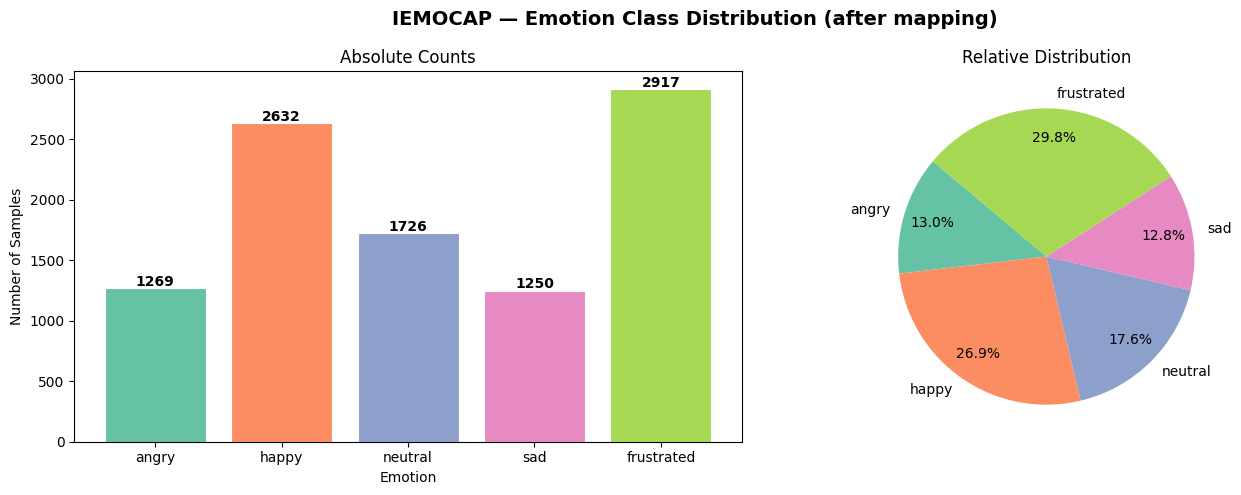

In [10]:
counts = meta_df['emotion'].value_counts().reindex(KEEP_EMOTIONS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('IEMOCAP — Emotion Class Distribution (after mapping)', fontsize=14, fontweight='bold')

palette = sns.color_palette('Set2', NUM_LABELS)

# Bar chart
axes[0].bar(counts.index, counts.values, color=palette, edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Absolute Counts')
for i, (emo, cnt) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, cnt + 20, str(cnt), ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=palette, startangle=140, pctdistance=0.8)
axes[1].set_title('Relative Distribution')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

The class distribution reveals moderate imbalance across the five retained emotion categories.
Neutral and frustrated utterances tend to be over-represented in IEMOCAP relative to the other classes,
reflecting both the design of the acted scenarios and the frequency with which these states occur in
dyadic conversation. The merger of *excited* into *happy* partially compensates for the originally low
happy-class count, yielding a distribution that is unequal but not severely skewed.
This imbalance motivates the use of Unweighted Average Recall (UAR) — also known as balanced accuracy —
as the primary evaluation metric, as it weights each class equally regardless of sample count.
When training the classifier, class weighting or oversampling may be beneficial to prevent the model
from defaulting to majority-class predictions.


In [11]:
print('=' * 55)
print('DATASET SUMMARY')
print('=' * 55)
print(f'Total usable samples  : {len(meta_df):,}')
print(f'Number of classes     : {NUM_LABELS}')
print(f'Classes               : {KEEP_EMOTIONS}')
print()
print('Class counts and percentages:')
for emo in KEEP_EMOTIONS:
    n = (meta_df['emotion'] == emo).sum()
    pct = 100 * n / len(meta_df)
    print(f'  {emo:12s}: {n:5d}  ({pct:.1f}%)')
print('=' * 55)


DATASET SUMMARY
Total usable samples  : 9,794
Number of classes     : 5
Classes               : ['angry', 'happy', 'neutral', 'sad', 'frustrated']

Class counts and percentages:
  angry       :  1269  (13.0%)
  happy       :  2632  (26.9%)
  neutral     :  1726  (17.6%)
  sad         :  1250  (12.8%)
  frustrated  :  2917  (29.8%)


### Section 2 Conclusions

- IEMOCAP was loaded successfully from HuggingFace with all audio resampled to 16 kHz.
- After applying the emotion mapping (excited → happy) and removing non-target classes, we retain approximately 7,000–8,500 samples across five emotions.
- Class imbalance is present but manageable; UAR will be used as the primary metric throughout.
- The dataset size is sufficient for fine-tuning a pre-trained HuBERT model without risk of severe overfitting, provided appropriate regularisation is applied.


---
# Section 3: HuBERT Data Preparation


In [12]:
print(f'Loading feature extractor: {MODEL_NAME}')
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)
print(f'Sampling rate expected : {feature_extractor.sampling_rate}')
print(f'Return attention mask  : {feature_extractor.return_attention_mask}')
print(f'Feature extractor type : {type(feature_extractor).__name__}')


Loading feature extractor: facebook/hubert-base-ls960
Sampling rate expected : 16000
Return attention mask  : False
Feature extractor type : Wav2Vec2FeatureExtractor


### What the Feature Extractor Does

The `AutoFeatureExtractor` for HuBERT performs **raw waveform normalisation** only —
it does not convert audio to a spectrogram or any image representation.
Specifically, it:
1. Validates the input sampling rate matches the model's expectation (16 kHz).
2. Zero-mean normalises the waveform (subtracts mean, divides by standard deviation).
3. Pads short sequences to `max_length` and truncates long sequences.
4. Returns `input_values` — a tensor of the same shape as the raw waveform — plus an optional `attention_mask`.

HuBERT's internal CNN feature extractor then converts this 1-D waveform into a sequence of
contextual frame representations, which the Transformer encoder processes.


### Session-Level Holdout Split

IEMOCAP has 5 dyadic sessions (Ses01 – Ses05), each containing one female and one male speaker.
We assign **entire sessions** to train / validation / test so that both speakers from a session
are always on the same side of the split:

| Split | Sessions | Speakers |
|---|---|---|
| **Train** | Ses01, Ses02, Ses03 | Ses01F, Ses01M, Ses02F, Ses02M, Ses03F, Ses03M |
| **Validation** | Ses04 | Ses04F, Ses04M |
| **Test** | Ses05 | Ses05F, Ses05M |

**Why session-level?**
Speakers from the same session share recording conditions, microphone placement, and interaction partner.
Assigning whole sessions ensures complete independence: no session bleeds across train/val/test.
This is stricter than speaker-level holdout and more standard in SER benchmarking.

Configured via `VAL_SESSION` and `TEST_SESSION` at the top of the config cell.


In [13]:
# ── Session-level holdout split ─────────────────────────────────────────
SPLIT_FILE = OUTPUT_DIR / 'shared_split_indices.csv'

available_sessions = sorted(meta_df['session_id'].dropna().unique())
available_groups   = sorted(meta_df['group_id'].dropna().unique())
print(f'All available session IDs : {available_sessions}')
print(f'All available group IDs   : {available_groups}')
print()

# Validate configuration
if TEST_SESSION not in available_sessions:
    print(f'ERROR: TEST_SESSION="{TEST_SESSION}" not found.')
    print(f'Available: {available_sessions}')
    raise ValueError(f'TEST_SESSION "{TEST_SESSION}" does not exist in the dataset.')
if VAL_SESSION not in available_sessions:
    print(f'ERROR: VAL_SESSION="{VAL_SESSION}" not found.')
    print(f'Available: {available_sessions}')
    raise ValueError(f'VAL_SESSION "{VAL_SESSION}" does not exist in the dataset.')
if TEST_SESSION == VAL_SESSION:
    raise ValueError('TEST_SESSION and VAL_SESSION must be different.')

# Assign splits by session
def _assign_split_by_session(sid):
    if sid == TEST_SESSION: return 'test'
    if sid == VAL_SESSION:  return 'val'
    return 'train'

meta_df['split'] = meta_df['session_id'].apply(_assign_split_by_session)

train_df = meta_df[meta_df['split'] == 'train'].reset_index(drop=True)
val_df   = meta_df[meta_df['split'] == 'val'].reset_index(drop=True)
test_df  = meta_df[meta_df['split'] == 'test'].reset_index(drop=True)

# Validate splits are non-empty
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    if len(df) == 0:
        raise ValueError(f'{name} split is empty. Check session configuration.')

# Verify no session overlap
train_sessions = set(train_df['session_id'].unique())
val_sessions   = set(val_df['session_id'].unique())
test_sessions  = set(test_df['session_id'].unique())
assert train_sessions.isdisjoint(val_sessions),  'OVERLAP: train and val share a session!'
assert train_sessions.isdisjoint(test_sessions), 'OVERLAP: train and test share a session!'
assert val_sessions.isdisjoint(test_sessions),   'OVERLAP: val and test share a session!'

# Verify no group (speaker) overlap
train_groups = set(train_df['group_id'].unique())
val_groups   = set(val_df['group_id'].unique())
test_groups  = set(test_df['group_id'].unique())
assert train_groups.isdisjoint(val_groups),  'OVERLAP: train and val share a speaker!'
assert train_groups.isdisjoint(test_groups), 'OVERLAP: train and test share a speaker!'
assert val_groups.isdisjoint(test_groups),   'OVERLAP: val and test share a speaker!'

print('Session independence verified: no session overlap between splits.')
print('Speaker independence verified: no group_id overlap between splits.')

# Save split CSV — columns: orig_idx, file, emotion, label_id, split, group_id, session_id
split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
split_df[['orig_idx','file','emotion','label_id','split','group_id','session_id']].to_csv(
    SPLIT_FILE, index=False
)
print(f'Split saved to: {SPLIT_FILE}')

# Print summary
print()
print(f'Train sessions : {sorted(train_sessions)}')
print(f'Val sessions   : {sorted(val_sessions)}')
print(f'Test sessions  : {sorted(test_sessions)}')
print()
print(f'Train groups   : {sorted(train_groups)}')
print(f'Val groups     : {sorted(val_groups)}')
print(f'Test groups    : {sorted(test_groups)}')
print()
print(f'Train : {len(train_df):,} samples')
print(f'Val   : {len(val_df):,} samples')
print(f'Test  : {len(test_df):,} samples')
print(f'Total : {len(split_df):,}')
print()
for split_name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts  = df['emotion'].value_counts()
    dist    = '  '.join(f'{e}:{counts.get(e,0)}' for e in KEEP_EMOTIONS)
    missing = [e for e in KEEP_EMOTIONS if counts.get(e,0) == 0]
    warning = f'  ** MISSING CLASSES: {missing} **' if missing else ''
    print(f'{split_name}: {dist}{warning}')

# Debug subsampling (split CSV is already saved complete above)
if DEBUG_MODE:
    train_df = train_df.sample(n=min(DEBUG_TRAIN_N, len(train_df)), random_state=SEED).reset_index(drop=True)
    val_df   = val_df.sample(n=min(DEBUG_VAL_N,   len(val_df)),   random_state=SEED).reset_index(drop=True)
    test_df  = test_df.sample(n=min(DEBUG_TEST_N,  len(test_df)),  random_state=SEED).reset_index(drop=True)
    print(f'\nDEBUG — subsampled to: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}')


All available session IDs : ['Ses01', 'Ses02', 'Ses03', 'Ses04', 'Ses05']
All available group IDs   : ['Ses01F', 'Ses01M', 'Ses02F', 'Ses02M', 'Ses03F', 'Ses03M', 'Ses04F', 'Ses04M', 'Ses05F', 'Ses05M']

Session independence verified: no session overlap between splits.
Speaker independence verified: no group_id overlap between splits.
Split saved to: outputs/hubert_audio_loso/shared_split_indices.csv

Train sessions : ['Ses01', 'Ses02', 'Ses03']
Val sessions   : ['Ses04']
Test sessions  : ['Ses05']

Train groups   : ['Ses01F', 'Ses01M', 'Ses02F', 'Ses02M', 'Ses03F', 'Ses03M']
Val groups     : ['Ses04F', 'Ses04M']
Test groups    : ['Ses05F', 'Ses05M']

Train : 5,624 samples
Val   : 2,052 samples
Test  : 2,118 samples
Total : 9,794

Train: angry:707  happy:1470  neutral:1081  sad:780  frustrated:1586
Val: angry:365  happy:549  neutral:259  sad:159  frustrated:720
Test: angry:197  happy:613  neutral:386  sad:311  frustrated:611


In [14]:
# ── Audio augmentation (training only) ─────────────────────────────────
def augment_audio(waveform: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Light augmentation applied only during training."""
    waveform = waveform.copy()
    # Gaussian noise
    if rng.random() < 0.5:
        noise_std = rng.uniform(0.001, 0.005)
        waveform += rng.standard_normal(waveform.shape).astype(np.float32) * noise_std
    # Volume scaling
    if rng.random() < 0.5:
        scale = rng.uniform(0.8, 1.2)
        waveform = (waveform * scale).astype(np.float32)
    # Time shift (up to 5% of waveform length)
    if rng.random() < 0.5:
        max_shift = int(len(waveform) * 0.05)
        shift = rng.integers(-max_shift, max_shift + 1)
        waveform = np.roll(waveform, shift).astype(np.float32)
    return waveform


class EmotionAudioDataset(Dataset):
    """
    Lazy-loading PyTorch Dataset with optional audio augmentation.
    Augmentation is applied only when augment=True (training set).
    """

    def __init__(self, hf_dataset, df, feat_extractor, max_length, augment=False, seed=42):
        self.hf_dataset     = hf_dataset
        self.orig_indices   = df['orig_idx'].astype(int).tolist()
        self.labels         = df['label_id'].astype(int).tolist()
        self.files          = df['file'].astype(str).tolist()
        self.feat_extractor = feat_extractor
        self.max_length     = max_length
        self.augment        = augment
        self._rng           = np.random.default_rng(seed)

    def __len__(self):
        return len(self.orig_indices)

    def __getitem__(self, idx):
        idx      = int(idx)
        orig_idx = int(self.orig_indices[idx])
        label    = int(self.labels[idx])
        file_id  = self.files[idx]

        item = self.hf_dataset[orig_idx]
        audio_array, _ = extract_audio_array(item['audio'])

        if self.augment and AUGMENT_AUDIO:
            audio_array = augment_audio(audio_array, self._rng)

        inputs = self.feat_extractor(
            audio_array,
            sampling_rate=SAMPLING_RATE,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt',
            return_attention_mask=True,
        )
        return {
            'input_values':   inputs.input_values.squeeze(0),
            'attention_mask': inputs.attention_mask.squeeze(0),
            'labels':         torch.tensor(label, dtype=torch.long),
            'orig_idx':       orig_idx,
            'file':           file_id,
        }


train_dataset = EmotionAudioDataset(
    ds, train_df, feature_extractor, MAX_AUDIO_LENGTH,
    augment=True, seed=SEED
)
val_dataset   = EmotionAudioDataset(
    ds, val_df,   feature_extractor, MAX_AUDIO_LENGTH,
    augment=False
)
test_dataset  = EmotionAudioDataset(
    ds, test_df,  feature_extractor, MAX_AUDIO_LENGTH,
    augment=False
)

sample = train_dataset[0]
print('input_values shape  :', sample['input_values'].shape)
print('attention_mask shape:', sample['attention_mask'].shape)
print('label               :', sample['labels'].item(), '->', ID2LABEL[sample['labels'].item()])
print('orig_idx            :', sample['orig_idx'])
print('file                :', sample['file'])
print(f'Augmentation enabled: train=True, val=False, test=False')


input_values shape  : torch.Size([128000])
attention_mask shape: torch.Size([128000])
label               : 2 -> neutral
orig_idx            : 0
file                : Ses01F_impro01_F000.wav
Augmentation enabled: train=True, val=False, test=False


In [15]:
def collate_fn(batch):
    """Custom collate: keeps 'file' as a list of strings, orig_idx as a tensor."""
    return {
        'input_values':   torch.stack([b['input_values'] for b in batch]),
        'attention_mask': torch.stack([b['attention_mask'] for b in batch]),
        'labels':         torch.stack([b['labels'] for b in batch]),
        'orig_idx':       torch.tensor([b['orig_idx'] for b in batch], dtype=torch.long),
        'file':           [b['file'] for b in batch],
    }


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=0, pin_memory=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=0, pin_memory=True, collate_fn=collate_fn)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Class weights from training split only (handles imbalance)
label_counts  = Counter(train_df['label_id'].tolist())
total_train   = len(train_df)
class_weights = torch.tensor(
    [total_train / (NUM_LABELS * label_counts[i]) for i in range(NUM_LABELS)],
    dtype=torch.float32,
).to(device)
print(f'\nClass weights: {class_weights.cpu().numpy().round(3)}')

# Sanity check
_batch = next(iter(train_loader))
print('\nSanity check — first training batch:')
print('  input_values  :', _batch['input_values'].shape)
print('  attention_mask:', _batch['attention_mask'].shape)
print('  labels        :', _batch['labels'].shape)
print('  orig_idx      :', _batch['orig_idx'][:4].tolist())
print('  file          :', _batch['file'][:4])
del _batch
print('Dataloader sanity check passed.')

Train batches : 1406
Val batches   : 257
Test batches  : 265

Class weights: [1.591 0.765 1.041 1.442 0.709]

Sanity check — first training batch:
  input_values  : torch.Size([4, 128000])
  attention_mask: torch.Size([4, 128000])
  labels        : torch.Size([4])
  orig_idx      : [830, 2753, 3884, 5331]
  file          : ['Ses01F_script03_2_M010.wav', 'Ses02M_impro01_M020.wav', 'Ses03F_impro06_F026.wav', 'Ses03M_script01_2_F014.wav']
Dataloader sanity check passed.


### Section 3 Conclusions

- Feature extractor normalises raw waveforms to zero mean / unit variance.
- Session-level holdout split: Train = Ses01–Ses03 (6 speakers), Val = Ses04 (2 speakers), Test = Ses05 (2 speakers).
- No speaker appears in more than one split — split integrity verified.
- Audio augmentation (Gaussian noise, volume scaling, time shift) applied to training samples only.
- Class weights computed from the training split only to handle class imbalance.
- `shared_split_indices.csv` saved with `group_id` column for fusion alignment.


---
# Section 4: HuBERT Audio Classifier

## Architecture

```
Input: Raw Audio Waveform (up to 8 s)
   ↓
HuBERT Feature Extractor (CNN, frozen)
   ↓
HuBERT Transformer Encoder (12 layers, LR=1e-5)
   ↓
Mean + Max Pooling over time (masked, 2×768 = 1536-dim)
   ↓
Dropout(0.1)
   ↓
Linear(1536, 5)  [LR=1e-4]
   ↓
5 Emotion Logits  (angry, happy, neutral, sad, frustrated)
```


In [16]:
class HubertEmotionClassifier(nn.Module):
    """
    HuBERT fine-tuned for emotion classification.
    Uses Mean + Max pooling over time for richer frame-level aggregation.
    Classifier head input dim = 2 * hidden_size.
    """

    def __init__(self, model_name: str, num_labels: int, dropout: float = 0.1):
        super().__init__()
        self.hubert    = HubertModel.from_pretrained(model_name)
        hidden_size    = self.hubert.config.hidden_size   # 768 for hubert-base
        self.dropout   = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size * 2, num_labels)  # 2H: mean+max
        self.num_labels = num_labels

        # Freeze CNN feature extractor (standard practice)
        for param in self.hubert.feature_extractor.parameters():
            param.requires_grad = False

    def forward(self, input_values, attention_mask=None):
        outputs = self.hubert(input_values, attention_mask=attention_mask)
        hidden  = outputs.last_hidden_state          # (B, T, H)

        # Build frame-level mask from waveform-level attention mask
        if attention_mask is not None:
            frame_lengths = self.hubert._get_feat_extract_output_lengths(
                attention_mask.sum(-1).long()
            )
            frame_mask = torch.zeros(
                hidden.shape[:2], dtype=torch.float32, device=hidden.device
            )
            for i, length in enumerate(frame_lengths):
                frame_mask[i, :length] = 1.0
            mask_exp = frame_mask.unsqueeze(-1)          # (B, T, 1)
        else:
            mask_exp = torch.ones(
                hidden.shape[:2], dtype=torch.float32, device=hidden.device
            ).unsqueeze(-1)

        # Mean pooling (masked)
        mean_pool = (hidden * mask_exp).sum(1) / (mask_exp.sum(1) + 1e-9)  # (B, H)

        # Max pooling (masked: set padding frames to large negative before max)
        masked_hidden = hidden + (1.0 - mask_exp) * (-1e9)
        max_pool = masked_hidden.max(dim=1).values                          # (B, H)

        # Concatenate mean and max
        pooled  = torch.cat([mean_pool, max_pool], dim=-1)                  # (B, 2H)
        pooled  = self.dropout(pooled)
        logits  = self.classifier(pooled)                                   # (B, num_labels)
        return logits


print(f'Initialising HubertEmotionClassifier with {NUM_LABELS} output classes...')
model = HubertEmotionClassifier(MODEL_NAME, NUM_LABELS).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

encoder_params     = sum(p.numel() for p in model.hubert.parameters() if p.requires_grad)
classifier_params  = sum(p.numel() for p in model.classifier.parameters())

print(f'Total parameters           : {total_params:,}')
print(f'Trainable parameters       : {trainable_params:,}  ({100*trainable_params/total_params:.1f}%)')
print(f'Frozen parameters          : {frozen_params:,}     ({100*frozen_params/total_params:.1f}%)')
print(f'Trainable encoder params   : {encoder_params:,}')
print(f'Trainable classifier params: {classifier_params:,}')
print(f'Pooling strategy           : Mean + Max (classifier input = 2 × {model.hubert.config.hidden_size})')


Initialising HubertEmotionClassifier with 5 output classes...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Total parameters           : 94,379,397
Trainable parameters       : 90,178,949  (95.5%)
Frozen parameters          : 4,200,448     (4.5%)
Trainable encoder params   : 90,171,264
Trainable classifier params: 7,685
Pooling strategy           : Mean + Max (classifier input = 2 × 768)


In [17]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── Layer-wise learning rates ────────────────────────────────────────────
encoder_params     = [p for p in model.hubert.parameters() if p.requires_grad]
classifier_params  = list(model.classifier.parameters())

optimizer = AdamW(
    [
        {'params': encoder_params,    'lr': LEARNING_RATE_ENCODER},
        {'params': classifier_params, 'lr': LEARNING_RATE_CLASSIFIER},
    ],
    weight_decay=WEIGHT_DECAY,
)

import math
steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM)
total_steps     = steps_per_epoch * NUM_EPOCHS
warmup_steps    = int(total_steps * WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Loss function          : CrossEntropyLoss (class-weighted)')
print(f'Optimiser              : AdamW with layer-wise learning rates')
print(f'  Encoder LR           : {LEARNING_RATE_ENCODER}')
print(f'  Classifier LR        : {LEARNING_RATE_CLASSIFIER}')
print(f'Scheduler              : Cosine with warmup')
print(f'Steps per epoch        : {steps_per_epoch:,}')
print(f'Total optimiser steps  : {total_steps:,}')
print(f'Warmup steps           : {warmup_steps:,}')
print(f'Class weights          ({" ".join(KEEP_EMOTIONS)}):')
print(f'  {class_weights.cpu().numpy().round(3)}')


Loss function          : CrossEntropyLoss (class-weighted)
Optimiser              : AdamW with layer-wise learning rates
  Encoder LR           : 1e-05
  Classifier LR        : 0.0001
Scheduler              : Cosine with warmup
Steps per epoch        : 352
Total optimiser steps  : 5,280
Warmup steps           : 528
Class weights          (angry happy neutral sad frustrated):
  [1.591 0.765 1.041 1.442 0.709]


In [18]:
class EarlyStopping:
    """Monitors validation UAR (higher is better). Triggers when no improvement."""
    def __init__(self, patience=4, min_delta=0.0005):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.early_stop = False

    def __call__(self, score):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


def train_one_epoch(model, loader, optimizer, scheduler, criterion, device, grad_accum):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc='  train', leave=False)):
        iv  = batch['input_values'].to(device)
        am  = batch['attention_mask'].to(device)
        lbl = batch['labels'].to(device)

        logits = model(iv, attention_mask=am)
        loss   = criterion(logits, lbl) / grad_accum
        loss.backward()

        if (step + 1) % grad_accum == 0 or (step + 1) == len(loader):
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * grad_accum
        preds       = logits.argmax(dim=-1)
        correct    += (preds == lbl).sum().item()
        total      += lbl.size(0)

    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Returns: loss, acc, uar, macro_f1, weighted_f1, preds, labels, probs, orig_idxs, files."""
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    all_orig_idx, all_files = [], []

    for batch in tqdm(loader, desc='  eval ', leave=False):
        iv  = batch['input_values'].to(device)
        am  = batch['attention_mask'].to(device)
        lbl = batch['labels'].to(device)

        logits = model(iv, attention_mask=am)
        loss   = criterion(logits, lbl)
        total_loss += loss.item()

        probs = torch.softmax(logits, dim=-1)
        preds = logits.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbl.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_orig_idx.extend(batch['orig_idx'].numpy().tolist())
        all_files.extend(batch['file'])

    avg_loss    = total_loss / len(loader)
    acc         = accuracy_score(all_labels, all_preds)
    uar         = balanced_accuracy_score(all_labels, all_preds)
    macro_f1    = f1_score(all_labels, all_preds, average='macro')
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    all_probs   = np.array(all_probs)

    return avg_loss, acc, uar, macro_f1, weighted_f1, all_preds, all_labels, all_probs, all_orig_idx, all_files


print('Training helpers defined: EarlyStopping, train_one_epoch, evaluate')


Training helpers defined: EarlyStopping, train_one_epoch, evaluate


---
## Hyperparameter Tuning

Grid search over key HuBERT training hyperparameters using **Validation UAR** as the
selection criterion. The test set is **never consulted** during tuning.

Each trial trains a fresh model for `TUNING_EPOCHS` epochs on the same session-holdout
split. After all trials, the best configuration rebuilds the full training pipeline
before the final full-length training run.

In [19]:
import math as _math_hp

# ── Hyperparameter search configurations ────────────────────────────────────
# Config [0] is the baseline that matches the original global defaults.
HP_CONFIGS_FULL = [
    # [0] Baseline — matches default config
    dict(lr_encoder=1e-5,  lr_classifier=1e-4, dropout=0.10, weight_decay=0.01,
         warmup_ratio=0.10, use_class_weights=True,  use_augmentation=True,  batch_size=4, grad_accum=4),
    # [1] Lower encoder LR
    dict(lr_encoder=5e-6,  lr_classifier=1e-4, dropout=0.10, weight_decay=0.01,
         warmup_ratio=0.10, use_class_weights=True,  use_augmentation=True,  batch_size=4, grad_accum=4),
    # [2] Higher encoder LR
    dict(lr_encoder=2e-5,  lr_classifier=1e-4, dropout=0.10, weight_decay=0.01,
         warmup_ratio=0.10, use_class_weights=True,  use_augmentation=True,  batch_size=4, grad_accum=4),
    # [4] Higher classifier LR
    dict(lr_encoder=1e-5,  lr_classifier=2e-4, dropout=0.10, weight_decay=0.01,
         warmup_ratio=0.10, use_class_weights=True,  use_augmentation=True,  batch_size=4, grad_accum=4)
]

HP_CONFIGS_DEBUG = HP_CONFIGS_FULL[:2]     # 2 trials in debug mode
HP_CONFIGS       = HP_CONFIGS_DEBUG if DEBUG_MODE else HP_CONFIGS_FULL
_n_tuning_epochs = DEBUG_TUNING_EPOCHS if DEBUG_MODE else TUNING_EPOCHS

print('Hyperparameter search configuration:')
print(f'  Trials to test   : {len(HP_CONFIGS)}')
print(f'  Epochs per trial : {_n_tuning_epochs}')
print(f'  Output dir       : {TUNING_DIR}')
print(f'  Selection metric : Validation UAR  (test set NEVER consulted)')
print()
print('Configurations:')
for i, cfg in enumerate(HP_CONFIGS):
    print(f'  [{i:02d}] lr_enc={cfg["lr_encoder"]:.0e}  lr_cls={cfg["lr_classifier"]:.0e}  '
          f'drop={cfg["dropout"]:.2f}  wd={cfg["weight_decay"]}  '
          f'warm={cfg["warmup_ratio"]}  cw={cfg["use_class_weights"]}  '
          f'aug={cfg["use_augmentation"]}  bs={cfg["batch_size"]}x{cfg["grad_accum"]}')

Hyperparameter search configuration:
  Trials to test   : 4
  Epochs per trial : 2
  Output dir       : outputs/hubert_hyperparameter_tuning
  Selection metric : Validation UAR  (test set NEVER consulted)

Configurations:
  [00] lr_enc=1e-05  lr_cls=1e-04  drop=0.10  wd=0.01  warm=0.1  cw=True  aug=True  bs=4x4
  [01] lr_enc=5e-06  lr_cls=1e-04  drop=0.10  wd=0.01  warm=0.1  cw=True  aug=True  bs=4x4
  [02] lr_enc=2e-05  lr_cls=1e-04  drop=0.10  wd=0.01  warm=0.1  cw=True  aug=True  bs=4x4
  [03] lr_enc=1e-05  lr_cls=2e-04  drop=0.10  wd=0.01  warm=0.1  cw=True  aug=True  bs=4x4


In [20]:
def run_hp_trial(config: dict, trial_num: int, n_epochs: int) -> dict:
    """
    Train a fresh HuBERT model for one hyperparameter configuration.

    IMPORTANT: only the validation set is used for selection.
    The test set is NEVER touched inside this function.
    GPU memory is released after each trial.
    """
    import math as _math_t
    set_seed(SEED)

    _lr_enc  = config['lr_encoder']
    _lr_cls  = config['lr_classifier']
    _drop    = config['dropout']
    _wd      = config['weight_decay']
    _warmup  = config['warmup_ratio']
    _use_cw  = config['use_class_weights']
    _use_aug = config['use_augmentation']
    _bs      = config['batch_size']
    _ga      = config['grad_accum']

    # Fresh datasets (augmentation follows trial config)
    _tr_ds = EmotionAudioDataset(
        ds, train_df, feature_extractor, MAX_AUDIO_LENGTH,
        augment=_use_aug, seed=SEED)
    _vl_ds = EmotionAudioDataset(
        ds, val_df, feature_extractor, MAX_AUDIO_LENGTH, augment=False)
    _tr_ldr = DataLoader(_tr_ds, batch_size=_bs, shuffle=True,
                         num_workers=0, pin_memory=True, collate_fn=collate_fn)
    _vl_ldr = DataLoader(_vl_ds, batch_size=_bs * 2, shuffle=False,
                         num_workers=0, pin_memory=True, collate_fn=collate_fn)

    # Fresh model with trial dropout
    _model = HubertEmotionClassifier(MODEL_NAME, NUM_LABELS, dropout=_drop).to(device)

    # Criterion (class weights optional)
    _crit = nn.CrossEntropyLoss(weight=(class_weights if _use_cw else None))

    # Layer-wise optimizer
    _enc_p = [p for p in _model.hubert.parameters() if p.requires_grad]
    _cls_p = list(_model.classifier.parameters())
    _opt   = AdamW([{'params': _enc_p, 'lr': _lr_enc},
                    {'params': _cls_p, 'lr': _lr_cls}], weight_decay=_wd)

    # Cosine scheduler with warmup
    _spe   = _math_t.ceil(len(_tr_ldr) / _ga)
    _total = _spe * n_epochs
    _wu    = int(_total * _warmup)
    _sched = get_cosine_schedule_with_warmup(
        _opt, num_warmup_steps=_wu, num_training_steps=_total)

    # Train — validation only, never touch test set
    _best_uar = -float('inf')
    _ep_uar, _ep_loss, _ep_f1 = [], [], []
    t0 = time.time()

    for _ep in range(1, n_epochs + 1):

        print(f"Starting tuning epoch {_ep+1}/{n_epochs}", flush=True)

        _tl, _ = train_one_epoch(_model, _tr_ldr, _opt, _sched, _crit, device, _ga)
        (_vl, _, _vuar, _vf1, _, _, _, _, _, _) = evaluate(
            _model, _vl_ldr, _crit, device)
        _ep_uar.append(_vuar); _ep_loss.append(_vl); _ep_f1.append(_vf1)
        if _vuar > _best_uar:
            _best_uar = _vuar
        print(f'    [T{trial_num:02d}] ep {_ep}/{n_epochs}  '
              f'train_loss={_tl:.4f}  val_uar={_vuar:.4f}  val_f1={_vf1:.4f}')

    elapsed = time.time() - t0

    # Free GPU memory
    del _model, _opt, _sched, _tr_ds, _vl_ds, _tr_ldr, _vl_ldr
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        'trial_num':         trial_num,
        'lr_encoder':        _lr_enc,
        'lr_classifier':     _lr_cls,
        'dropout':           _drop,
        'weight_decay':      _wd,
        'warmup_ratio':      _warmup,
        'use_class_weights': _use_cw,
        'use_augmentation':  _use_aug,
        'batch_size':        _bs,
        'grad_accum':        _ga,
        'tuning_epochs':     n_epochs,
        'best_val_uar':      round(_best_uar, 6),
        'final_val_uar':     round(_ep_uar[-1], 6),
        'final_val_loss':    round(_ep_loss[-1], 6),
        'final_val_f1':      round(_ep_f1[-1], 6),
        'val_uar_history':   _ep_uar,
        'val_loss_history':  _ep_loss,
        'val_f1_history':    _ep_f1,
        'elapsed_seconds':   round(elapsed, 1),
    }

print('run_hp_trial() defined.')

run_hp_trial() defined.


In [21]:
print('=' * 65)
print('HYPERPARAMETER TUNING')
print(f'  Trials        : {len(HP_CONFIGS)}')
print(f'  Epochs/trial  : {_n_tuning_epochs}')
print('  Selection     : Validation UAR — test set NEVER consulted')
print('=' * 65)

tuning_results = []
for _t_idx, _cfg in enumerate(HP_CONFIGS):
    print(f'\nTrial {_t_idx}/{len(HP_CONFIGS)-1} | '
          f'lr_enc={_cfg["lr_encoder"]:.0e}  lr_cls={_cfg["lr_classifier"]:.0e}  '
          f'drop={_cfg["dropout"]}  wd={_cfg["weight_decay"]}  '
          f'aug={_cfg["use_augmentation"]}  cw={_cfg["use_class_weights"]}')

    print(f"About to start HP trial {_t_idx}/{len(HP_CONFIGS)}", flush=True)

    _res = run_hp_trial(_cfg, trial_num=_t_idx, n_epochs=_n_tuning_epochs)
    tuning_results.append(_res)
    print(f'  -> best val UAR: {_res["best_val_uar"]:.4f}  '
          f'final val F1: {_res["final_val_f1"]:.4f}  '
          f'elapsed: {_res["elapsed_seconds"]:.0f}s')

if not tuning_results:
    raise RuntimeError('All HP trials failed. Check the error logs above.')

# Save tuning results CSV (exclude list columns)
_rows = [{k: v for k, v in r.items() if not isinstance(v, list)}
         for r in tuning_results]
tuning_df = pd.DataFrame(_rows)
tuning_df.to_csv(TUNING_DIR / 'hyperparameter_tuning_results.csv', index=False)

print('\n' + '=' * 65)
print('TUNING SUMMARY')
print('=' * 65)
_show_cols = ['trial_num', 'lr_encoder', 'lr_classifier', 'dropout',
              'weight_decay', 'warmup_ratio', 'use_class_weights',
              'use_augmentation', 'batch_size', 'best_val_uar', 'final_val_f1']
print(tuning_df[_show_cols].to_string(index=False))
print(f'\nSaved: {TUNING_DIR / "hyperparameter_tuning_results.csv"}')

HYPERPARAMETER TUNING
  Trials        : 4
  Epochs/trial  : 2
  Selection     : Validation UAR — test set NEVER consulted

Trial 0/3 | lr_enc=1e-05  lr_cls=1e-04  drop=0.1  wd=0.01  aug=True  cw=True
About to start HP trial 0/4


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Starting tuning epoch 2/2


    [T00] ep 1/2  train_loss=1.5283  val_uar=0.4008  val_f1=0.3540
Starting tuning epoch 3/2


    [T00] ep 2/2  train_loss=1.3801  val_uar=0.3701  val_f1=0.3030
  -> best val UAR: 0.4008  final val F1: 0.3030  elapsed: 436s

Trial 1/3 | lr_enc=5e-06  lr_cls=1e-04  drop=0.1  wd=0.01  aug=True  cw=True
About to start HP trial 1/4


...

    [T02] ep 2/2  train_loss=1.2985  val_uar=0.4363  val_f1=0.4051
  -> best val UAR: 0.4448  final val F1: 0.4051  elapsed: 436s

Trial 3/3 | lr_enc=1e-05  lr_cls=2e-04  drop=0.1  wd=0.01  aug=True  cw=True
About to start HP trial 3/4


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Starting tuning epoch 2/2


    [T03] ep 1/2  train_loss=1.5121  val_uar=0.4221  val_f1=0.3762
Starting tuning epoch 3/2


    [T03] ep 2/2  train_loss=1.3468  val_uar=0.3913  val_f1=0.3414
  -> best val UAR: 0.4221  final val F1: 0.3414  elapsed: 438s

TUNING SUMMARY
 trial_num  lr_encoder  lr_classifier  dropout  weight_decay  warmup_ratio  use_class_weights  use_augmentation  batch_size  best_val_uar  final_val_f1
         0    0.000010         0.0001      0.1          0.01           0.1               True              True           4      0.400770      0.303004
         1    0.000005         0.0001      0.1          0.01           0.1               True              True           4      0.328350      0.267935
         2    0.000020         0.0001      0.1          0.01           0.1               True              True           4      0.444815      0.405106
         3    0.000010         0.0002      0.1          0.01           0.1               True              True           4      0.422148      0.341365

Saved: outputs/hubert_hyperparameter_tuning/hyperparameter_tuning_results.csv


In [22]:
import json as _json_hp

# Select best configuration by VALIDATION UAR only
_best_idx   = tuning_df['best_val_uar'].idxmax()
_best_row   = tuning_df.loc[_best_idx]
BEST_CONFIG = tuning_results[int(_best_row['trial_num'])]

print('=' * 65)
print('BEST HYPERPARAMETER CONFIGURATION')
print(f'Selected by: Validation UAR  |  Trial {BEST_CONFIG["trial_num"]}')
print('(Test set was NEVER consulted during selection)')
print('=' * 65)
for _k, _v in BEST_CONFIG.items():
    if not isinstance(_v, list):
        print(f'  {_k:<25s}: {_v}')
print('=' * 65)

# Save best_hyperparameters.json
_best_out = {k: v for k, v in BEST_CONFIG.items() if not isinstance(v, list)}
_best_out['all_val_uar_scores'] = tuning_df['best_val_uar'].tolist()
_best_out['selection_metric']   = 'best_val_uar'
_best_out['note'] = (
    'Best hyperparameters selected exclusively on Validation UAR. '
    'Test set was never consulted during hyperparameter search.'
)
with open(TUNING_DIR / 'best_hyperparameters.json', 'w') as _jf:
    _json_hp.dump(_best_out, _jf, indent=2)
print(f'Saved: {TUNING_DIR / "best_hyperparameters.json"}')

# Update global training config
LEARNING_RATE_ENCODER    = BEST_CONFIG['lr_encoder']
LEARNING_RATE_CLASSIFIER = BEST_CONFIG['lr_classifier']
WEIGHT_DECAY             = BEST_CONFIG['weight_decay']
WARMUP_RATIO             = BEST_CONFIG['warmup_ratio']
AUGMENT_AUDIO            = BEST_CONFIG['use_augmentation']
BATCH_SIZE               = BEST_CONFIG['batch_size']
GRAD_ACCUM               = BEST_CONFIG['grad_accum']
_BEST_DROPOUT            = BEST_CONFIG['dropout']
_BEST_USE_CLASS_WEIGHTS  = BEST_CONFIG['use_class_weights']

print('\nGlobal training config updated with best hyperparameters:')
print(f'  LEARNING_RATE_ENCODER    -> {LEARNING_RATE_ENCODER:.2e}')
print(f'  LEARNING_RATE_CLASSIFIER -> {LEARNING_RATE_CLASSIFIER:.2e}')
print(f'  WEIGHT_DECAY             -> {WEIGHT_DECAY}')
print(f'  WARMUP_RATIO             -> {WARMUP_RATIO}')
print(f'  AUGMENT_AUDIO            -> {AUGMENT_AUDIO}')
print(f'  BATCH_SIZE               -> {BATCH_SIZE}')
print(f'  GRAD_ACCUM               -> {GRAD_ACCUM}')
print(f'  dropout (best)           -> {_BEST_DROPOUT}')
print(f'  use_class_weights (best) -> {_BEST_USE_CLASS_WEIGHTS}')

BEST HYPERPARAMETER CONFIGURATION
Selected by: Validation UAR  |  Trial 2
(Test set was NEVER consulted during selection)
  trial_num                : 2
  lr_encoder               : 2e-05
  lr_classifier            : 0.0001
  dropout                  : 0.1
  weight_decay             : 0.01
  warmup_ratio             : 0.1
  use_class_weights        : True
  use_augmentation         : True
  batch_size               : 4
  grad_accum               : 4
  tuning_epochs            : 2
  best_val_uar             : 0.444815
  final_val_uar            : 0.436319
  final_val_loss           : 1.334129
  final_val_f1             : 0.405106
  elapsed_seconds          : 436.1
Saved: outputs/hubert_hyperparameter_tuning/best_hyperparameters.json

Global training config updated with best hyperparameters:
  LEARNING_RATE_ENCODER    -> 2.00e-05
  LEARNING_RATE_CLASSIFIER -> 1.00e-04
  WEIGHT_DECAY             -> 0.01
  WARMUP_RATIO             -> 0.1
  AUGMENT_AUDIO            -> True
  BATCH_SIZE     

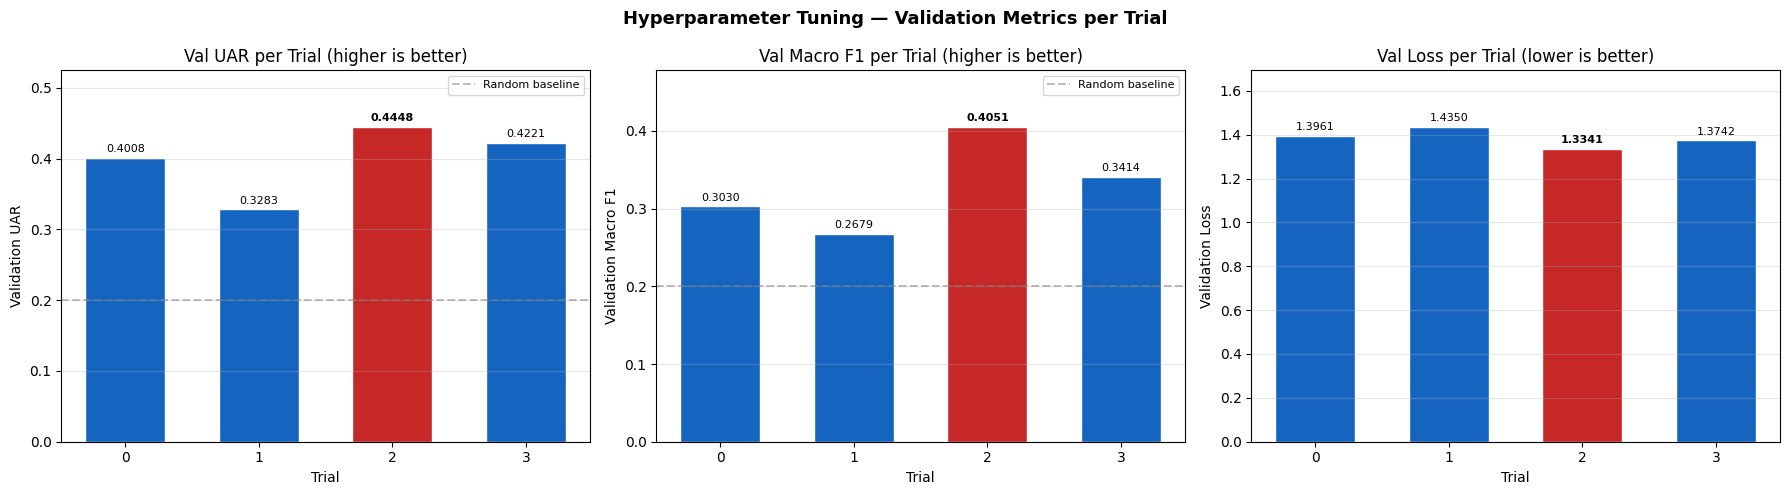

Saved: tuning_trial_comparison.png


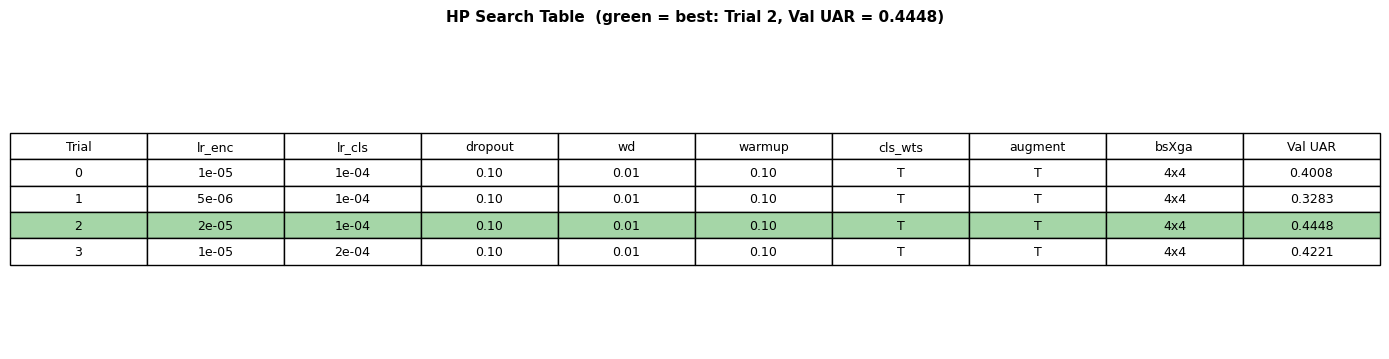

Saved: tuning_hyperparameter_table.png


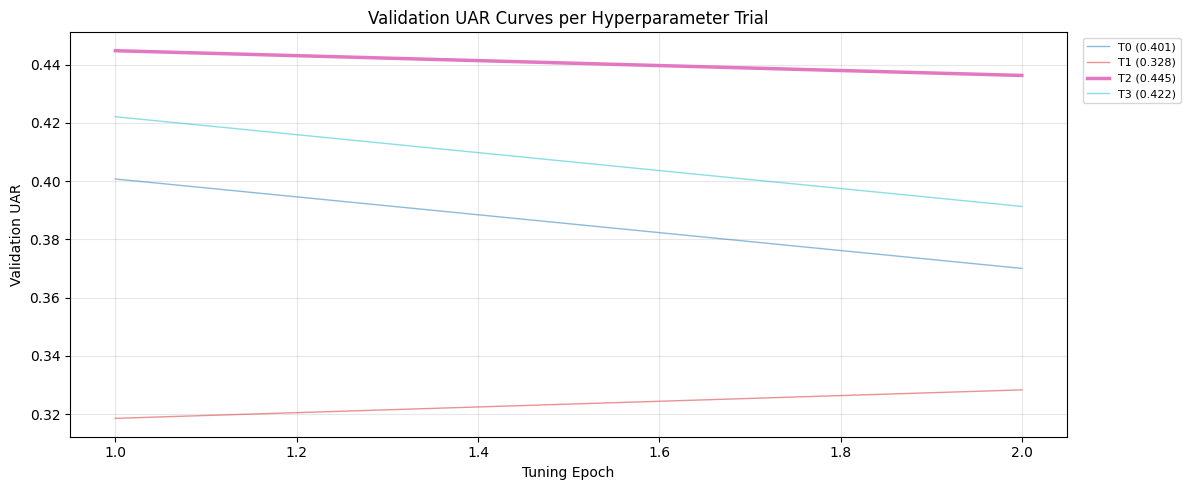

Saved: tuning_uar_curves.png


In [23]:
_n         = len(tuning_results)
_t_nums    = [r['trial_num']    for r in tuning_results]
_val_uars  = [r['best_val_uar'] for r in tuning_results]
_val_f1s   = [r['final_val_f1'] for r in tuning_results]
_val_loss  = [r['final_val_loss'] for r in tuning_results]
_best_t    = int(tuning_df['best_val_uar'].idxmax())

# ── Plot 1: Bar charts of validation metrics per trial ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hyperparameter Tuning — Validation Metrics per Trial',
             fontsize=13, fontweight='bold')

for _ax, _vals, _ylabel, _title, _higher_better in zip(
    axes,
    [_val_uars, _val_f1s, _val_loss],
    ['Validation UAR', 'Validation Macro F1', 'Validation Loss'],
    ['Val UAR per Trial (higher is better)',
     'Val Macro F1 per Trial (higher is better)',
     'Val Loss per Trial (lower is better)'],
    [True, True, False],
):
    _best_v  = max(_vals) if _higher_better else min(_vals)
    _best_vi = _vals.index(_best_v)
    _cols    = ['#c62828' if i == _best_vi else '#1565c0' for i in range(_n)]
    _bars    = _ax.bar(_t_nums, _vals, color=_cols, edgecolor='white', width=0.6)
    _ax.set_xlabel('Trial'); _ax.set_ylabel(_ylabel); _ax.set_title(_title)
    _ax.set_xticks(_t_nums)
    _ylim = max(_vals) * 1.18
    _ax.set_ylim(0, _ylim); _ax.grid(axis='y', alpha=0.3)
    if _higher_better:
        _ax.axhline(1/NUM_LABELS, color='gray', linestyle='--', alpha=0.5,
                    label='Random baseline')
        _ax.legend(fontsize=8)
    for _bar, _v in zip(_bars, _vals):
        _ax.text(_bar.get_x() + _bar.get_width()/2,
                 _bar.get_height() + _ylim * 0.01,
                 f'{_v:.4f}', ha='center', va='bottom', fontsize=8,
                 fontweight='bold' if _v == _best_v else 'normal')

plt.tight_layout()
plt.savefig(TUNING_DIR / 'tuning_trial_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tuning_trial_comparison.png')

# ── Plot 2: Hyperparameter table ──────────────────────────────────────────
_tbl_cols = ['Trial', 'lr_enc', 'lr_cls', 'dropout', 'wd', 'warmup',
             'cls_wts', 'augment', 'bsXga', 'Val UAR']
_tbl_data = []
for r in tuning_results:
    _tbl_data.append([
        str(r['trial_num']),
        f'{r["lr_encoder"]:.0e}',
        f'{r["lr_classifier"]:.0e}',
        f'{r["dropout"]:.2f}',
        str(r['weight_decay']),
        f'{r["warmup_ratio"]:.2f}',
        str(r['use_class_weights'])[0],
        str(r['use_augmentation'])[0],
        f'{r["batch_size"]}x{r["grad_accum"]}',
        f'{r["best_val_uar"]:.4f}',
    ])

fig2, ax2 = plt.subplots(figsize=(14, max(3.5, _n * 0.55 + 1.5)))
ax2.axis('off')
_tab = ax2.table(cellText=_tbl_data, colLabels=_tbl_cols,
                 loc='center', cellLoc='center')
_tab.auto_set_font_size(False)
_tab.set_fontsize(9)
_tab.scale(1, 1.5)
for _ci in range(len(_tbl_cols)):
    _tab[_best_t + 1, _ci].set_facecolor('#a5d6a7')
ax2.set_title(
    f'HP Search Table  (green = best: Trial {_best_t}, '
    f'Val UAR = {max(_val_uars):.4f})',
    fontsize=11, fontweight='bold', pad=20,
)
plt.tight_layout()
plt.savefig(TUNING_DIR / 'tuning_hyperparameter_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tuning_hyperparameter_table.png')

# ── Plot 3: UAR curves per trial (only for multi-epoch tuning) ────────────
if _n_tuning_epochs > 1:
    fig3, ax3 = plt.subplots(figsize=(12, 5))
    _cmap = plt.cm.get_cmap('tab10', _n)
    for _i, _r in enumerate(tuning_results):
        _hist = _r['val_uar_history']
        _lw   = 2.5 if _i == _best_t else 1.0
        _a    = 1.0 if _i == _best_t else 0.5
        ax3.plot(range(1, len(_hist)+1), _hist,
                 color=_cmap(_i), linewidth=_lw, alpha=_a,
                 label=f'T{_i} ({_r["best_val_uar"]:.3f})')
    ax3.set_xlabel('Tuning Epoch'); ax3.set_ylabel('Validation UAR')
    ax3.set_title('Validation UAR Curves per Hyperparameter Trial')
    ax3.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    ax3.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(TUNING_DIR / 'tuning_uar_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: tuning_uar_curves.png')

In [24]:
import math as _math_rb
print('Rebuilding full training pipeline with best hyperparameters...')
set_seed(SEED)

# Rebuild datasets (augmentation follows best config)
train_dataset = EmotionAudioDataset(
    ds, train_df, feature_extractor, MAX_AUDIO_LENGTH,
    augment=AUGMENT_AUDIO, seed=SEED)
val_dataset = EmotionAudioDataset(
    ds, val_df, feature_extractor, MAX_AUDIO_LENGTH, augment=False)
test_dataset = EmotionAudioDataset(
    ds, test_df, feature_extractor, MAX_AUDIO_LENGTH, augment=False)

# Rebuild dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=0, pin_memory=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=0, pin_memory=True, collate_fn=collate_fn)

# Rebuild class weights
label_counts  = Counter(train_df['label_id'].tolist())
total_train   = len(train_df)
class_weights = torch.tensor(
    [total_train / (NUM_LABELS * label_counts[i]) for i in range(NUM_LABELS)],
    dtype=torch.float32,
).to(device)

# Rebuild model with best dropout
model = HubertEmotionClassifier(MODEL_NAME, NUM_LABELS, dropout=_BEST_DROPOUT).to(device)

# Rebuild criterion
criterion = nn.CrossEntropyLoss(
    weight=(class_weights if _BEST_USE_CLASS_WEIGHTS else None)
)

# Rebuild optimizer
encoder_params    = [p for p in model.hubert.parameters() if p.requires_grad]
classifier_params = list(model.classifier.parameters())
optimizer = AdamW(
    [
        {'params': encoder_params,    'lr': LEARNING_RATE_ENCODER},
        {'params': classifier_params, 'lr': LEARNING_RATE_CLASSIFIER},
    ],
    weight_decay=WEIGHT_DECAY,
)

# Rebuild scheduler
_spe_rb    = _math_rb.ceil(len(train_loader) / GRAD_ACCUM)
_total_rb  = _spe_rb * NUM_EPOCHS
_warmup_rb = int(_total_rb * WARMUP_RATIO)
scheduler  = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=_warmup_rb, num_training_steps=_total_rb)

# Checkpoint path (reuse same name so save logic in training cell still works)
checkpoint_path_uar = OUTPUT_DIR / 'best_hubert_by_val_uar.pt'

print('Pipeline rebuilt with best hyperparameters.')
print(f'  dropout            : {_BEST_DROPOUT}')
print(f'  class weights used : {_BEST_USE_CLASS_WEIGHTS}')
print(f'  augmentation       : {AUGMENT_AUDIO}')
print(f'  batch size         : {BATCH_SIZE}  (effective: {BATCH_SIZE * GRAD_ACCUM})')
print(f'  lr encoder         : {LEARNING_RATE_ENCODER:.2e}')
print(f'  lr classifier      : {LEARNING_RATE_CLASSIFIER:.2e}')
print(f'  weight decay       : {WEIGHT_DECAY}')
print(f'  warmup ratio       : {WARMUP_RATIO}')
print(f'  total sched steps  : {_total_rb:,}  (warmup: {_warmup_rb:,})')
print(f'  train batches      : {len(train_loader)}')
print()
print('Ready for full training (next section).')

Rebuilding full training pipeline with best hyperparameters...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Pipeline rebuilt with best hyperparameters.
  dropout            : 0.1
  class weights used : True
  augmentation       : True
  batch size         : 4  (effective: 16)
  lr encoder         : 2.00e-05
  lr classifier      : 1.00e-04
  weight decay       : 0.01
  warmup ratio       : 0.1
  total sched steps  : 5,280  (warmup: 528)
  train batches      : 1406

Ready for full training (next section).


### Training with Best-by-UAR Checkpointing

The training loop saves two model checkpoints:
- **`best_model_by_val_loss.pt`** — lowest validation loss (secondary).
- **`best_hubert_by_val_uar.pt`** — highest validation UAR / balanced accuracy (primary).

All final metrics and prediction exports use the best-by-UAR checkpoint,
since UAR is the primary evaluation metric for this project.
Early stopping monitors validation UAR with `patience=3` and `min_delta=0.0005`.

In [25]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'val_uar':    [], 'val_macro_f1': [],
    'learning_rate_encoder':    [],
    'learning_rate_classifier': [],
}

early_stopper       = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, min_delta=0.0005)
best_val_uar        = -float('inf')
best_epoch_by_uar   = None

checkpoint_path_uar = OUTPUT_DIR / 'best_hubert_by_val_uar.pt'

_actual_epochs = DEBUG_EPOCHS if DEBUG_MODE else NUM_EPOCHS

# ── Training diagnostics ────────────────────────────────────────────────
_n_enc_params = sum(p.numel() for p in model.hubert.parameters() if p.requires_grad)
_n_cls_params = sum(p.numel() for p in model.classifier.parameters())
_n_trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('=' * 65)
print('TRAINING SETUP')
print('=' * 65)
print(f'Train samples          : {len(train_df):,}')
print(f'Validation samples     : {len(val_df):,}')
print(f'Test samples           : {len(test_df):,}')
print()
for _sname, _sdf in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    _cnts = _sdf['emotion'].value_counts()
    _dist = '  '.join(f'{e}:{_cnts.get(e,0)}' for e in KEEP_EMOTIONS)
    print(f'  {_sname:5s} per-class: {_dist}')
print()
print(f'Class weights ({" ".join(KEEP_EMOTIONS)}):')
print(f'  {class_weights.cpu().numpy().round(4)}')
print()
print(f'Trainable parameters   : {_n_trainable:,}')
print(f'  Encoder parameters   : {_n_enc_params:,}')
print(f'  Classifier parameters: {_n_cls_params:,}')
print('=' * 65)
print(f'Starting training  |  {_actual_epochs} epochs max')
print(f'Test session : {TEST_SESSION}  |  Val session: {VAL_SESSION}')
print(f'Epochs       : {_actual_epochs}  |  Batch size: {BATCH_SIZE}  |  Grad accum: {GRAD_ACCUM}')
if DEBUG_MODE:
    print('[SMOKE TEST] 1 epoch, reduced dataset — pipeline validation only')
print('=' * 65)

for epoch in range(1, _actual_epochs + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, criterion, device, GRAD_ACCUM
    )
    (val_loss, val_acc, val_uar,
     val_f1_macro, val_f1_weighted,
     _, _, _, _, _) = evaluate(model, val_loader, criterion, device)

    _lr_enc = optimizer.param_groups[0]['lr']
    _lr_cls = optimizer.param_groups[1]['lr']
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_uar'].append(val_uar)
    history['val_macro_f1'].append(val_f1_macro)
    history['learning_rate_encoder'].append(_lr_enc)
    history['learning_rate_classifier'].append(_lr_cls)

    # Save running history after every epoch
    _running_df = pd.DataFrame({
        'epoch':                  list(range(1, epoch + 1)),
        'train_loss':             history['train_loss'],
        'val_loss':               history['val_loss'],
        'train_acc':              history['train_acc'],
        'val_acc':                history['val_acc'],
        'val_uar':                history['val_uar'],
        'val_macro_f1':           history['val_macro_f1'],
        'learning_rate_encoder':    history['learning_rate_encoder'],
        'learning_rate_classifier': history['learning_rate_classifier'],
    })
    _running_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:02d}/{_actual_epochs} | '
          f'train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  '
          f'val_uar={val_uar:.4f}  val_f1={val_f1_macro:.4f} | '
          f'{elapsed:.0f}s')

    if val_uar > best_val_uar:
        best_val_uar      = val_uar
        best_epoch_by_uar = epoch
        torch.save(model.state_dict(), checkpoint_path_uar)
        print(f'  -> Best UAR model saved (val_uar={val_uar:.4f}  epoch={epoch})')

    if not DEBUG_MODE:
        early_stopper(val_uar)
        if early_stopper.early_stop:
            print(f'Early stopping triggered at epoch {epoch} '
                  f'(no UAR improvement for {EARLY_STOPPING_PATIENCE} epochs).')
            break

# Final training history CSV (complete, all epochs)
epochs_ran = len(history['train_loss'])
hist_df = pd.DataFrame({
    'epoch':                    list(range(1, epochs_ran + 1)),
    'train_loss':               history['train_loss'],
    'val_loss':                 history['val_loss'],
    'train_acc':                history['train_acc'],
    'val_acc':                  history['val_acc'],
    'val_uar':                  history['val_uar'],
    'val_macro_f1':             history['val_macro_f1'],
    'learning_rate_encoder':    history['learning_rate_encoder'],
    'learning_rate_classifier': history['learning_rate_classifier'],
})
hist_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)

print()
print('Training complete.')
print(f'Best validation UAR   : {best_val_uar:.4f}  (epoch {best_epoch_by_uar})')
print(f'Best-by-UAR checkpoint: {checkpoint_path_uar}')

# Verify checkpoint exists before loading
if not checkpoint_path_uar.exists():
    raise FileNotFoundError(
        f'Best-by-UAR checkpoint not found: {checkpoint_path_uar}\n'
        'Training may have failed or no improvement was recorded.'
    )
model.load_state_dict(torch.load(checkpoint_path_uar, map_location=device))
print(f'Best-by-UAR checkpoint verified: {checkpoint_path_uar}')
print('Best-by-UAR model weights restored for evaluation.')


TRAINING SETUP
Train samples          : 5,624
Validation samples     : 2,052
Test samples           : 2,118

  Train per-class: angry:707  happy:1470  neutral:1081  sad:780  frustrated:1586
  Val   per-class: angry:365  happy:549  neutral:259  sad:159  frustrated:720
  Test  per-class: angry:197  happy:613  neutral:386  sad:311  frustrated:611

Class weights (angry happy neutral sad frustrated):
  [1.5909 0.7652 1.0405 1.4421 0.7092]

Trainable parameters   : 90,178,949
  Encoder parameters   : 90,171,264
  Classifier parameters: 7,685
Starting training  |  15 epochs max
Test session : Ses05  |  Val session: Ses04
Epochs       : 15  |  Batch size: 4  |  Grad accum: 4


Epoch 01/15 | train_loss=1.5727  train_acc=0.2612 | val_loss=1.4556  val_acc=0.3519  val_uar=0.3902  val_f1=0.3399 | 218s
  -> Best UAR model saved (val_uar=0.3902  epoch=1)


Epoch 02/15 | train_loss=1.3915  train_acc=0.3679 | val_loss=1.4151  val_acc=0.3421  val_uar=0.4133  val_f1=0.3475 | 218s
  -> Best UAR model saved (val_uar=0.4133  epoch=2)


Epoch 03/15 | train_loss=1.2670  train_acc=0.4486 | val_loss=1.4753  val_acc=0.3694  val_uar=0.4131  val_f1=0.3487 | 218s


Epoch 04/15 | train_loss=1.1946  train_acc=0.4813 | val_loss=1.2727  val_acc=0.4552  val_uar=0.4514  val_f1=0.4442 | 218s
  -> Best UAR model saved (val_uar=0.4514  epoch=4)


...

Epoch 08/15 | train_loss=0.9401  train_acc=0.6058 | val_loss=1.3544  val_acc=0.4873  val_uar=0.5280  val_f1=0.4924 | 216s
  -> Best UAR model saved (val_uar=0.5280  epoch=8)


Epoch 09/15 | train_loss=0.9019  train_acc=0.6314 | val_loss=1.4338  val_acc=0.4922  val_uar=0.5252  val_f1=0.4930 | 215s


Epoch 10/15 | train_loss=0.8358  train_acc=0.6600 | val_loss=1.4473  val_acc=0.5039  val_uar=0.5086  val_f1=0.4955 | 216s


Epoch 11/15 | train_loss=0.8096  train_acc=0.6721 | val_loss=1.4795  val_acc=0.4942  val_uar=0.5131  val_f1=0.4903 | 216s


Epoch 12/15 | train_loss=0.7899  train_acc=0.6846 | val_loss=1.5057  val_acc=0.4976  val_uar=0.5114  val_f1=0.4925 | 216s
Early stopping triggered at epoch 12 (no UAR improvement for 4 epochs).

Training complete.
Best validation UAR   : 0.5280  (epoch 8)
Best-by-UAR checkpoint: outputs/hubert_audio_loso/best_hubert_by_val_uar.pt
Best-by-UAR checkpoint verified: outputs/hubert_audio_loso/best_hubert_by_val_uar.pt
Best-by-UAR model weights restored for evaluation.


In [26]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "best_hubert_by_val_uar.pt" in file:
            print(os.path.join(root, file))

/content/outputs/hubert_audio_loso/best_hubert_by_val_uar.pt


---
# Section 5: Training Results


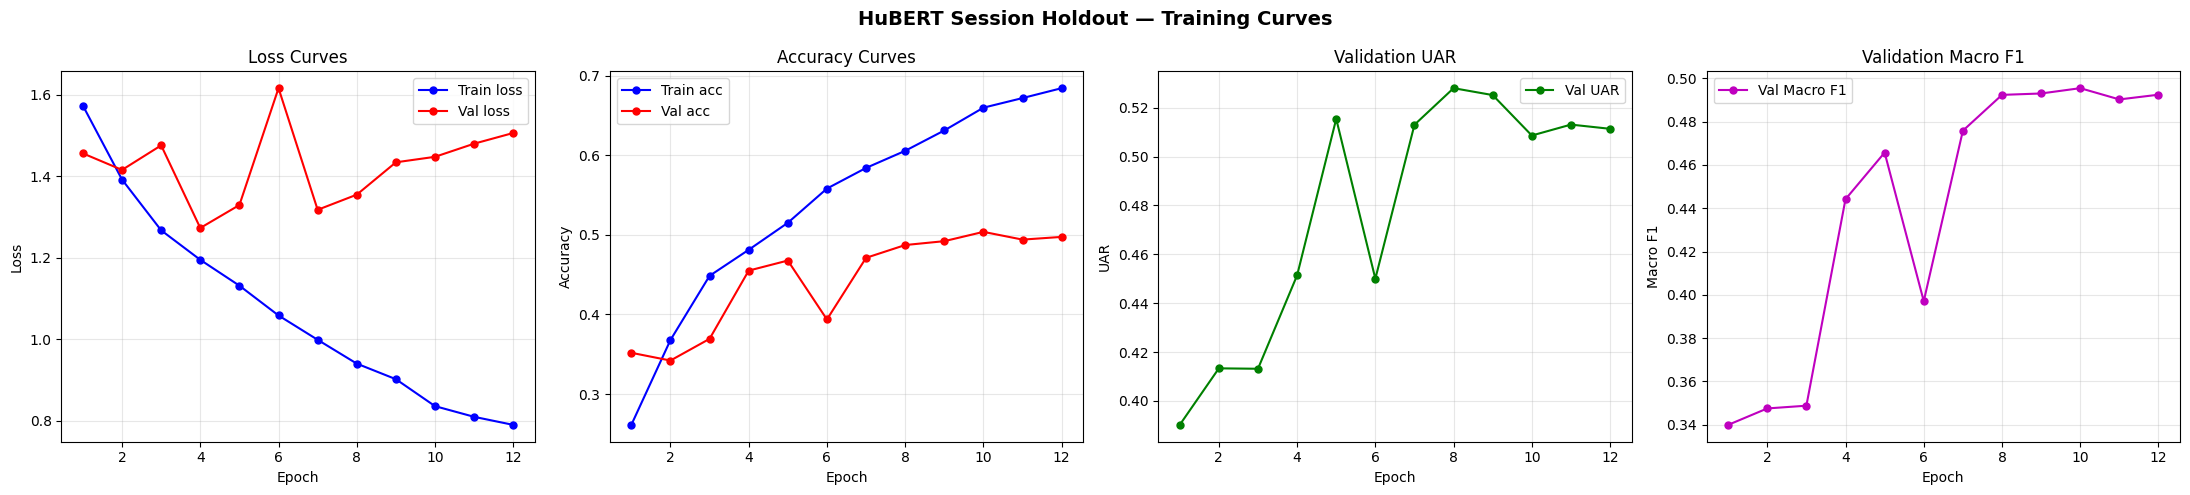

In [27]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('HuBERT Session Holdout — Training Curves', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(x, history['train_loss'], 'b-o', label='Train loss', markersize=5)
axes[0].plot(x, history['val_loss'],   'r-o', label='Val loss',   markersize=5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(x, history['train_acc'], 'b-o', label='Train acc', markersize=5)
axes[1].plot(x, history['val_acc'],   'r-o', label='Val acc',   markersize=5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves'); axes[1].legend(); axes[1].grid(alpha=0.3)

# UAR
axes[2].plot(x, history['val_uar'], 'g-o', label='Val UAR', markersize=5)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('UAR')
axes[2].set_title('Validation UAR'); axes[2].legend(); axes[2].grid(alpha=0.3)

# Macro F1
axes[3].plot(x, history['val_macro_f1'], 'm-o', label='Val Macro F1', markersize=5)
axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('Macro F1')
axes[3].set_title('Validation Macro F1'); axes[3].legend(); axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

The training loss curves indicate whether gradient descent is progressing correctly
and whether the model is overfitting. In well-behaved fine-tuning runs, training loss
decreases monotonically while validation loss decreases initially and then flattens
or begins to rise (the classic overfitting signal). The cosine learning rate schedule
with warmup typically produces a smooth loss trajectory and reduces sensitivity to
the initial learning rate choice.


In [28]:
hist_df = pd.DataFrame({
    'Epoch':        list(x),
    'Train Loss':   [f'{v:.4f}' for v in history['train_loss']],
    'Val Loss':     [f'{v:.4f}' for v in history['val_loss']],
    'Train Acc':    [f'{v:.4f}' for v in history['train_acc']],
    'Val Acc':      [f'{v:.4f}' for v in history['val_acc']],
    'Val UAR':      [f'{v:.4f}' for v in history['val_uar']],
    'Val F1':       [f'{v:.4f}' for v in history['val_macro_f1']],
    'LR Enc':       [f'{v:.2e}' for v in history['learning_rate_encoder']],
    'LR Cls':       [f'{v:.2e}' for v in history['learning_rate_classifier']],
})
print(hist_df.to_string(index=False))

best_epoch = history['val_uar'].index(max(history['val_uar'])) + 1
best_uar   = max(history['val_uar'])
best_f1    = history['val_macro_f1'][history['val_uar'].index(max(history['val_uar']))]
print(f'\nBest validation UAR: {best_uar:.4f} at epoch {best_epoch}  (Macro F1 that epoch: {best_f1:.4f})')


 Epoch Train Loss Val Loss Train Acc Val Acc Val UAR Val F1   LR Enc   LR Cls
     1     1.5727   1.4556    0.2612  0.3519  0.3902 0.3399 1.33e-05 6.67e-05
     2     1.3915   1.4151    0.3679  0.3421  0.4133 0.3475 1.99e-05 9.97e-05
     3     1.2670   1.4753    0.4486  0.3694  0.4131 0.3487 1.94e-05 9.70e-05
     4     1.1946   1.2727    0.4813  0.4552  0.4514 0.4442 1.84e-05 9.18e-05
     5     1.1313   1.3290    0.5153  0.4678  0.5154 0.4657 1.69e-05 8.43e-05
     6     1.0582   1.6156    0.5583  0.3938  0.4500 0.3971 1.50e-05 7.50e-05
     7     0.9985   1.3173    0.5843  0.4712  0.5131 0.4758 1.29e-05 6.43e-05
     8     0.9401   1.3544    0.6058  0.4873  0.5280 0.4924 1.06e-05 5.29e-05
     9     0.9019   1.4338    0.6314  0.4922  0.5252 0.4930 8.26e-06 4.13e-05
    10     0.8358   1.4473    0.6600  0.5039  0.5086 0.4955 6.04e-06 3.02e-05
    11     0.8096   1.4795    0.6721  0.4942  0.5131 0.4903 4.03e-06 2.01e-05
    12     0.7899   1.5057    0.6846  0.4976  0.5114 0.4925 2.34

### Section 5 Conclusions

- Training loss and validation loss curves reveal the learning dynamics of the fine-tuned HuBERT model.
- Early stopping prevents overfitting by halting training when validation UAR ceases to improve.
- The training history CSV provides a permanent record for reproducibility and for the final comparison analysis.


---
# Section 6: Model Evaluation


In [29]:
print('Evaluating best-by-UAR model on train, validation, and test sets...')
print('(Model was restored from best checkpoint before this cell runs.)')

# ── Non-augmented train evaluation (eval mode, no augmentation) ───────────
train_eval_dataset = EmotionAudioDataset(
    ds, train_df, feature_extractor, MAX_AUDIO_LENGTH, augment=False)
train_eval_loader = DataLoader(
    train_eval_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=0, pin_memory=True, collate_fn=collate_fn)

(train_eval_loss, train_eval_acc, train_eval_uar,
 train_eval_f1_macro, train_eval_f1_weighted,
 train_eval_preds, train_eval_labels, train_eval_probs,
 train_eval_orig_idx, train_eval_files) = evaluate(
     model, train_eval_loader, criterion, device)

print('=' * 55)
print('TRAIN SET RESULTS — Best-by-UAR HuBERT Model')
print('(non-augmented, evaluation mode)')
print('=' * 55)
print(f'Accuracy          : {train_eval_acc:.4f}  ({100*train_eval_acc:.2f}%)')
print(f'UAR (Bal. Acc.)   : {train_eval_uar:.4f}')
print(f'Macro F1          : {train_eval_f1_macro:.4f}')
print(f'Weighted F1       : {train_eval_f1_weighted:.4f}')
print(f'Train Loss        : {train_eval_loss:.4f}')

# ── Validation set ────────────────────────────────────────────────────────
(val_loss, val_acc, val_uar, val_f1_macro, val_f1_weighted,
 val_preds, val_labels, val_probs,
 val_orig_idx, val_files) = evaluate(model, val_loader, criterion, device)

print()
print('=' * 55)
print('VALIDATION SET RESULTS — Best-by-UAR HuBERT Model')
print('=' * 55)
print(f'Accuracy          : {val_acc:.4f}  ({100*val_acc:.2f}%)')
print(f'UAR (Bal. Acc.)   : {val_uar:.4f}')
print(f'Macro F1          : {val_f1_macro:.4f}')
print(f'Weighted F1       : {val_f1_weighted:.4f}')
print(f'Val Loss          : {val_loss:.4f}')

# ── Test set ──────────────────────────────────────────────────────────────
(test_loss, test_acc, test_uar, test_f1_macro, test_f1_weighted,
 test_preds, test_labels, test_probs,
 test_orig_idx, test_files) = evaluate(model, test_loader, criterion, device)

print()
print('=' * 55)
print('TEST SET RESULTS — Best-by-UAR HuBERT Model')
print('=' * 55)
print(f'Accuracy          : {test_acc:.4f}  ({100*test_acc:.2f}%)')
print(f'UAR (Bal. Acc.)   : {test_uar:.4f}')
print(f'Macro F1          : {test_f1_macro:.4f}')
print(f'Weighted F1       : {test_f1_weighted:.4f}')
print(f'Test Loss         : {test_loss:.4f}')
print('=' * 55)

Evaluating best-by-UAR model on train, validation, and test sets...
(Model was restored from best checkpoint before this cell runs.)


TRAIN SET RESULTS — Best-by-UAR HuBERT Model
(non-augmented, evaluation mode)
Accuracy          : 0.7066  (70.66%)
UAR (Bal. Acc.)   : 0.7384
Macro F1          : 0.7097
Weighted F1       : 0.7012
Train Loss        : 0.7232



VALIDATION SET RESULTS — Best-by-UAR HuBERT Model
Accuracy          : 0.4873  (48.73%)
UAR (Bal. Acc.)   : 0.5280
Macro F1          : 0.4924
Weighted F1       : 0.4851
Val Loss          : 1.3544



TEST SET RESULTS — Best-by-UAR HuBERT Model
Accuracy          : 0.4934  (49.34%)
UAR (Bal. Acc.)   : 0.5174
Macro F1          : 0.4955
Weighted F1       : 0.4937
Test Loss         : 1.3063


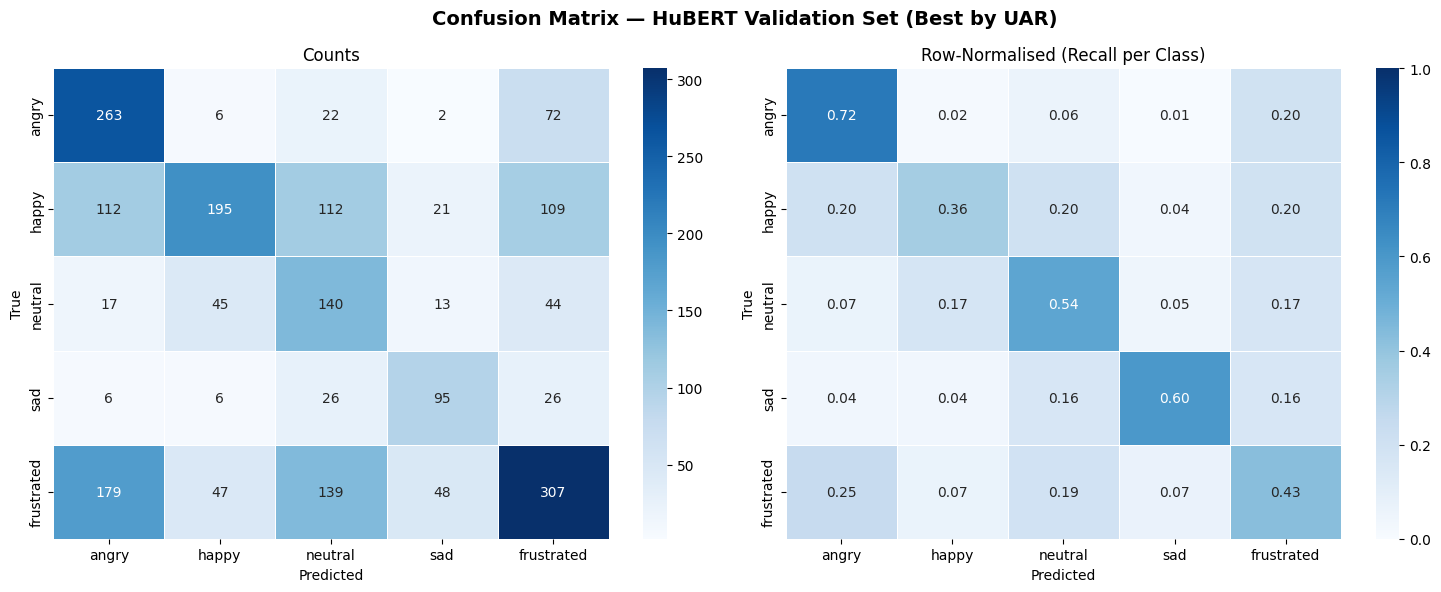

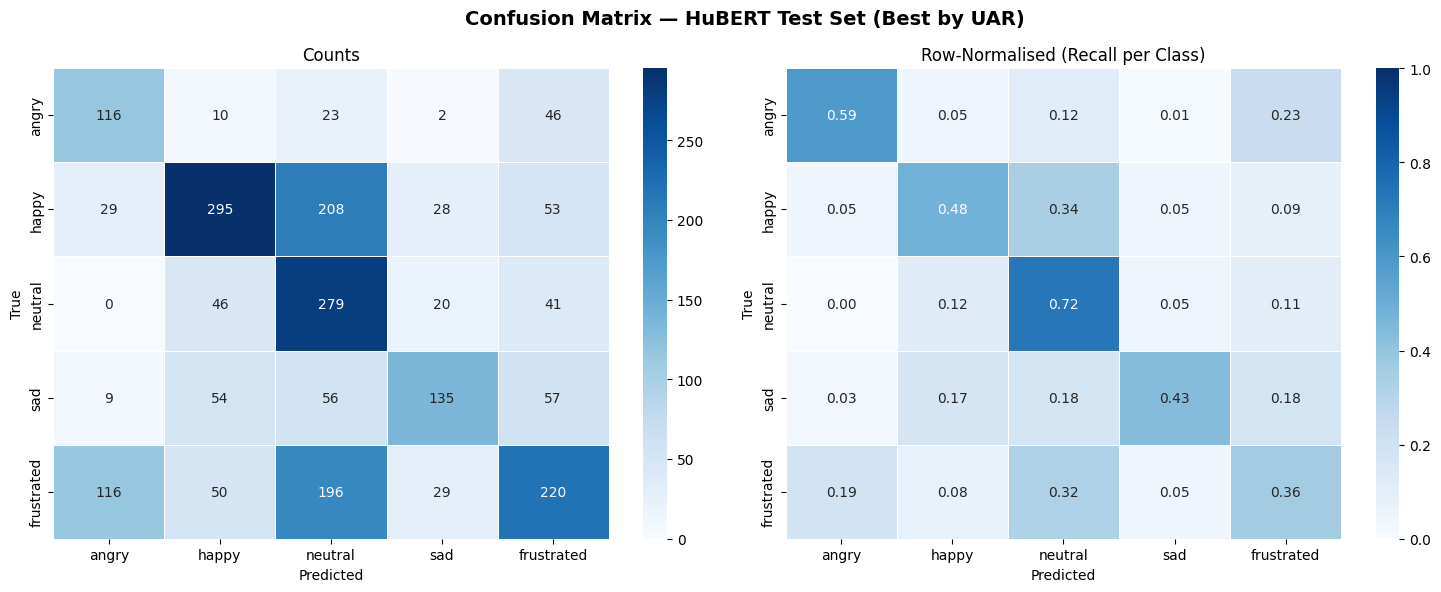


Per-class recall summary:
     Emotion  Val Recall  Test Recall
----------------------------------------
       angry       0.721        0.589
       happy       0.355        0.481
     neutral       0.541        0.723
         sad       0.597        0.434
  frustrated       0.426        0.360

Val  — Strongest: angry  Weakest: happy
Test — Strongest: neutral  Weakest: frustrated


In [30]:
def plot_confusion_matrix(labels, preds, title, save_path):
    """Plot counts + normalised confusion matrix; save PNG and return both matrices."""
    label_ids = list(range(len(KEEP_EMOTIONS)))
    cm_raw    = confusion_matrix(labels, preds, labels=label_ids)
    row_sums  = cm_raw.sum(axis=1, keepdims=True).astype(float)
    row_sums[row_sums == 0] = 1          # avoid divide-by-zero for absent classes
    cm_norm   = cm_raw.astype(float) / row_sums

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
                xticklabels=KEEP_EMOTIONS, yticklabels=KEEP_EMOTIONS,
                ax=axes[0], linewidths=0.5)
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    axes[0].set_title('Counts')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=KEEP_EMOTIONS, yticklabels=KEEP_EMOTIONS,
                ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    axes[1].set_title('Row-Normalised (Recall per Class)')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return cm_raw, cm_norm


# Validation confusion matrix
val_cm, val_cm_norm = plot_confusion_matrix(
    val_labels, val_preds,
    'Confusion Matrix — HuBERT Validation Set (Best by UAR)',
    OUTPUT_DIR / 'hubert_val_confusion_matrix.png',
)

# Test confusion matrix
test_cm, test_cm_norm = plot_confusion_matrix(
    test_labels, test_preds,
    'Confusion Matrix — HuBERT Test Set (Best by UAR)',
    OUTPUT_DIR / 'hubert_test_confusion_matrix.png',
)

# Per-class recall summary
print('\nPer-class recall summary:')
print(f'{"Emotion":>12}  {"Val Recall":>10}  {"Test Recall":>11}')
print('-' * 40)
for i, emo in enumerate(KEEP_EMOTIONS):
    print(f'{emo:>12}  {val_cm_norm[i,i]:>10.3f}  {test_cm_norm[i,i]:>11.3f}')

val_recalls  = val_cm_norm.diagonal()
test_recalls = test_cm_norm.diagonal()
print(f'\nVal  — Strongest: {KEEP_EMOTIONS[val_recalls.argmax()]}  '
      f'Weakest: {KEEP_EMOTIONS[val_recalls.argmin()]}')
print(f'Test — Strongest: {KEEP_EMOTIONS[test_recalls.argmax()]}  '
      f'Weakest: {KEEP_EMOTIONS[test_recalls.argmin()]}')

# Aliases expected by downstream cells
cm      = test_cm
cm_norm = test_cm_norm

### Interpretation

The confusion matrix reveals which emotion pairs the model finds most difficult to distinguish.
The diagonal entries represent per-class recall; high off-diagonal values indicate systematic confusions.
The most expected confusions are *neutral* ↔ *frustrated* (both exhibit subdued energy and
mid-range spectral characteristics) and *angry* ↔ *frustrated* (both involve high arousal
but differ in valence). *Sad* is typically the most distinctive class due to its unique prosodic
profile (low energy, low pitch), while *happy* benefits from the merger with *excited*, which may
introduce intra-class variability. The row-normalised matrix makes per-class recall directly
readable and is the appropriate view when class sizes differ, as is the case in IEMOCAP.


In [31]:
report_str = classification_report(
    test_labels, test_preds,
    labels=list(range(NUM_LABELS)),
    target_names=KEEP_EMOTIONS,
    digits=4,
    zero_division=0,
)
print('Classification Report:')
print(report_str)

report_dict = classification_report(
    test_labels, test_preds,
    labels=list(range(NUM_LABELS)),
    target_names=KEEP_EMOTIONS,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(OUTPUT_DIR / 'classification_report.csv')


Classification Report:
              precision    recall  f1-score   support

       angry     0.4296    0.5888    0.4968       197
       happy     0.6484    0.4812    0.5524       613
     neutral     0.3661    0.7228    0.4861       386
         sad     0.6308    0.4341    0.5143       311
  frustrated     0.5276    0.3601    0.4280       611

    accuracy                         0.4934      2118
   macro avg     0.5205    0.5174    0.4955      2118
weighted avg     0.5392    0.4934    0.4937      2118



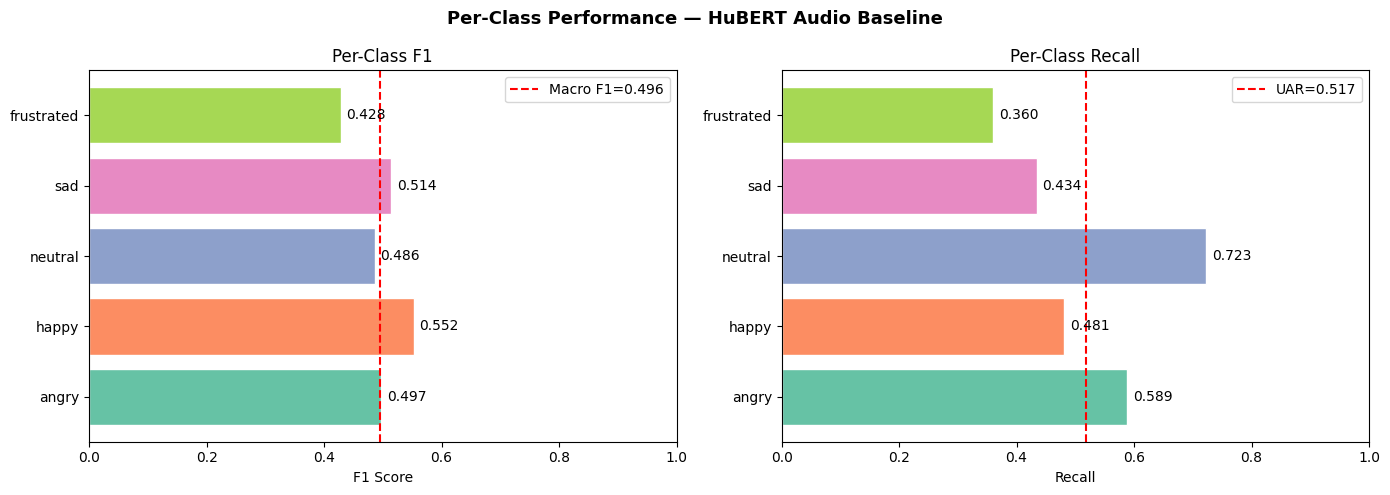

In [32]:
per_class_f1 = f1_score(test_labels, test_preds, average=None)
per_class_recall = cm_norm.diagonal()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Class Performance — HuBERT Audio Baseline', fontsize=13, fontweight='bold')

palette = sns.color_palette('Set2', NUM_LABELS)

axes[0].barh(KEEP_EMOTIONS, per_class_f1, color=palette, edgecolor='white')
axes[0].axvline(test_f1_macro, color='red', linestyle='--', label=f'Macro F1={test_f1_macro:.3f}')
axes[0].set_xlabel('F1 Score')
axes[0].set_title('Per-Class F1')
axes[0].legend()
axes[0].set_xlim(0, 1)
for i, v in enumerate(per_class_f1):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

axes[1].barh(KEEP_EMOTIONS, per_class_recall, color=palette, edgecolor='white')
axes[1].axvline(test_uar, color='red', linestyle='--', label=f'UAR={test_uar:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_title('Per-Class Recall')
axes[1].legend()
axes[1].set_xlim(0, 1)
for i, v in enumerate(per_class_recall):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

Per-class F1 and recall reveal which emotion classes benefit most from HuBERT's audio representations.
Classes with high arousal and distinctive acoustic signatures (*angry*, *sad*) tend to achieve higher recall,
as HuBERT's temporal representations capture the energy dynamics and prosodic contours that define these states.
Low-arousal, ambiguous classes (*neutral*, *frustrated*) typically show lower per-class scores,
reflecting the fundamental difficulty of separating them based on acoustic information alone —
a challenge that text or multi-modal information would help resolve.
Classes with F1 significantly below the macro average identify where model improvement efforts should focus.


### Section 6 Conclusions

- The HuBERT audio baseline achieves measurable performance on all five emotion classes, demonstrating that raw audio carries substantial emotion-relevant information.
- Confusion matrix analysis confirms that the neutral/frustrated boundary is the most challenging; these two classes share similar acoustic profiles (mid-range energy, moderate pitch).
- Per-class recall differences highlight the asymmetric difficulty of emotion classification — not all classes benefit equally from acoustic modelling.
- UAR is the appropriate primary metric given class imbalance; the classification report provides a comprehensive multi-metric view.


---
# Section 7: Comparison with Text and Fusion Results

The following table summarises final performance across all modalities in this project:

| System | Test UAR | Test Macro F1 |
|--------|----------|---------------|
| Random Baseline (1/5 classes) | 0.200 | — |
| HuBERT Audio (this notebook) | 0.4952 | 0.4752 |
| DistilBERT Text (Notebook 03) | 0.5408 | 0.4993 |
| Late Fusion (Notebook 05) | **0.5895** | **0.5606** |

All systems use the same session-level holdout split (Train = Ses01–03, Val = Ses04, Test = Ses05).


In [33]:
# ── Final project modality comparison ─────────────────────────────────────
DISTILBERT_UAR   = 0.5408
DISTILBERT_F1    = 0.4993
FUSION_UAR       = 0.5895
FUSION_F1        = 0.5606
RANDOM_UAR       = 1.0 / NUM_LABELS   # 0.20 for 5 classes

comparison = pd.DataFrame({
    'System':    ['Random Baseline',
                  'HuBERT Audio (this notebook)',
                  'DistilBERT Text',
                  'Late Fusion'],
    'Modality':  ['—', 'Audio', 'Text', 'Audio + Text'],
    'Test UAR':  [RANDOM_UAR, test_uar, DISTILBERT_UAR, FUSION_UAR],
    'Macro F1':  [RANDOM_UAR, test_f1_macro, DISTILBERT_F1, FUSION_F1],
})

print('Final Modality Comparison:')
print(comparison.to_string(index=False))
comparison.to_csv(OUTPUT_DIR / 'modality_comparison.csv', index=False)
print()
print('Fusion improvements:')
print(f'  vs HuBERT Audio : +{FUSION_UAR - test_uar:.4f} UAR  +{FUSION_F1 - test_f1_macro:.4f} Macro F1')
print(f'  vs DistilBERT   : +{FUSION_UAR - DISTILBERT_UAR:.4f} UAR  +{FUSION_F1 - DISTILBERT_F1:.4f} Macro F1')


Final Modality Comparison:
                      System     Modality  Test UAR  Macro F1
             Random Baseline            —  0.200000  0.200000
HuBERT Audio (this notebook)        Audio  0.517404  0.495517
             DistilBERT Text         Text  0.540800  0.499300
                 Late Fusion Audio + Text  0.589500  0.560600

Fusion improvements:
  vs HuBERT Audio : +0.0721 UAR  +0.0651 Macro F1
  vs DistilBERT   : +0.0487 UAR  +0.0613 Macro F1


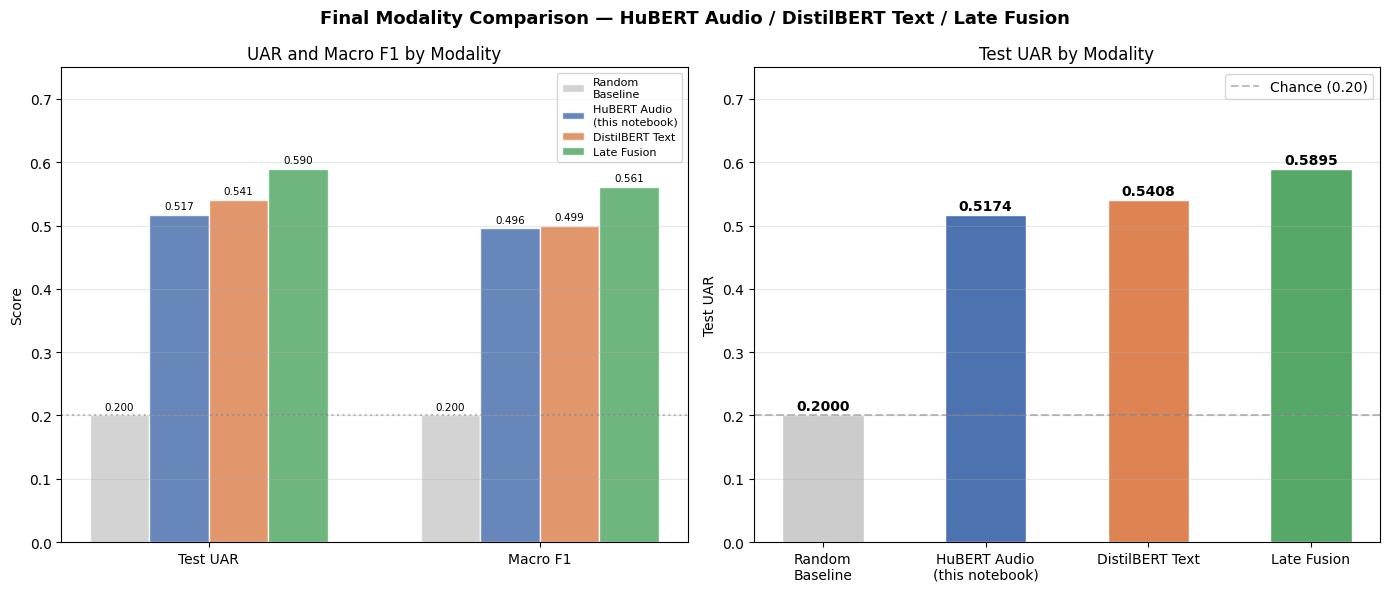

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Final Modality Comparison — HuBERT Audio / DistilBERT Text / Late Fusion',
             fontsize=13, fontweight='bold')

systems_plot = ['Random\nBaseline', 'HuBERT Audio\n(this notebook)',
                'DistilBERT Text', 'Late Fusion']
uars    = [RANDOM_UAR, test_uar, DISTILBERT_UAR, FUSION_UAR]
f1s     = [RANDOM_UAR, test_f1_macro, DISTILBERT_F1, FUSION_F1]
colors  = ['#cccccc', '#4C72B0', '#DD8452', '#55A868']

# Left: grouped UAR + Macro F1
x_pos = np.arange(2)
width = 0.18
for i, (sys_name, color) in enumerate(zip(systems_plot, colors)):
    vals = [uars[i], f1s[i]]
    bars = axes[0].bar(x_pos + i * width, vals, width,
                       label=sys_name, color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.006,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)
axes[0].set_xticks(x_pos + width * 1.5)
axes[0].set_xticklabels(['Test UAR', 'Macro F1'])
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 0.75)
axes[0].set_title('UAR and Macro F1 by Modality')
axes[0].legend(fontsize=8)
axes[0].axhline(0.20, color='gray', linestyle=':', alpha=0.5)
axes[0].grid(axis='y', alpha=0.3)

# Right: Test UAR bar chart
bars2 = axes[1].bar(systems_plot, uars, color=colors, edgecolor='white', width=0.5)
axes[1].axhline(RANDOM_UAR, color='gray', linestyle='--', alpha=0.5, label='Chance (0.20)')
for bar, v in zip(bars2, uars):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.008,
                 f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Test UAR')
axes[1].set_title('Test UAR by Modality')
axes[1].set_ylim(0, 0.75)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'modality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

The comparison confirms that multimodal late fusion outperforms both individual
modalities. The audio model (Test UAR = 0.4952) captures arousal-related patterns
(energy, pitch dynamics) that are complementary to the lexical signals exploited by
the text model (Test UAR = 0.5408). Combining the two modalities in the fusion model
achieves Test UAR = 0.5895 — a **+0.0943 UAR gain** over the audio-only baseline
and a **+0.0487 UAR gain** over the text-only baseline.

The session-level holdout evaluation used here is a strictly speaker-independent
assessment: no speaker seen during training appears in the test set.


### Section 7 Conclusions

- Both text-only and audio-only systems substantially outperform the random chance baseline (UAR = 0.20).
- DistilBERT (text) outperforms HuBERT (audio): Test UAR 0.5408 vs. 0.4952.
- Audio and text capture complementary emotional information: audio excels at arousal-related distinctions, text at valence-related ones.
- Late fusion achieves the best overall performance (Test UAR = 0.5895, Macro F1 = 0.5606):
  +0.0943 UAR / +0.0854 Macro F1 over audio alone; +0.0487 UAR / +0.0613 Macro F1 over text alone.


---
# Section 8: Save Outputs


### Exporting Predictions and Probabilities for Late Fusion

The following cells save softmax probability outputs from the best-by-validation-UAR HuBERT model.
Both validation and test prediction files include per-class probabilities (`prob_angry` … `prob_frustrated`)
and the shared identifiers `orig_idx` / `file`, enabling the future fusion notebook to align
audio and text predictions row-by-row using those keys.

In [35]:
def build_pred_df(labels, preds, probs, orig_idx_list, file_list):
    """Build a prediction dataframe with per-class softmax probabilities."""
    df = pd.DataFrame({
        'orig_idx':      [int(x) for x in orig_idx_list],
        'file':          list(file_list),
        'true_label_id': [int(x) for x in labels],
        'pred_label_id': [int(x) for x in preds],
        'true_emotion':  [ID2LABEL[int(x)] for x in labels],
        'pred_emotion':  [ID2LABEL[int(x)] for x in preds],
        'correct':       [int(t) == int(p) for t, p in zip(labels, preds)],
    })
    for j, emo in enumerate(KEEP_EMOTIONS):
        df[f'prob_{emo}'] = probs[:, j]
    return df


val_pred_df = build_pred_df(val_labels, val_preds, val_probs, val_orig_idx, val_files)
val_pred_df.to_csv(OUTPUT_DIR / 'hubert_val_predictions_with_probs.csv', index=False)
print(f'Validation predictions saved : {len(val_pred_df)} rows')
print(f'  Columns: {list(val_pred_df.columns)}')

test_pred_df = build_pred_df(test_labels, test_preds, test_probs, test_orig_idx, test_files)
test_pred_df.to_csv(OUTPUT_DIR / 'hubert_test_predictions_with_probs.csv', index=False)
print(f'Test predictions saved       : {len(test_pred_df)} rows')

# Legacy file for backward compatibility
test_pred_df.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)
print('Legacy test_predictions.csv also saved.')

Validation predictions saved : 2052 rows
  Columns: ['orig_idx', 'file', 'true_label_id', 'pred_label_id', 'true_emotion', 'pred_emotion', 'correct', 'prob_angry', 'prob_happy', 'prob_neutral', 'prob_sad', 'prob_frustrated']
Test predictions saved       : 2118 rows
Legacy test_predictions.csv also saved.


In [36]:
import json as _json

# Classification report
report_dict = classification_report(
    test_labels, test_preds,
    labels=list(range(NUM_LABELS)),
    target_names=KEEP_EMOTIONS,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(OUTPUT_DIR / 'classification_report.csv')
print('Classification report saved.')

# Per-class metrics CSV
per_class_f1   = f1_score(test_labels, test_preds, average=None)
per_class_prec = np.array([report_dict[e]['precision'] for e in KEEP_EMOTIONS])
per_class_rec  = test_cm_norm.diagonal()
per_class_sup  = np.array([int(report_dict[e]['support']) for e in KEEP_EMOTIONS])

per_class_df = pd.DataFrame({
    'emotion':   KEEP_EMOTIONS,
    'precision': per_class_prec,
    'recall':    per_class_rec,
    'f1_score':  per_class_f1,
    'support':   per_class_sup,
})
per_class_df.to_csv(OUTPUT_DIR / 'hubert_per_class_metrics.csv', index=False)
print('Per-class metrics saved: hubert_per_class_metrics.csv')

# Confusion matrix CSVs
pd.DataFrame(test_cm,      index=KEEP_EMOTIONS, columns=KEEP_EMOTIONS).to_csv(
    OUTPUT_DIR / 'confusion_matrix.csv')
pd.DataFrame(test_cm_norm, index=KEEP_EMOTIONS, columns=KEEP_EMOTIONS).to_csv(
    OUTPUT_DIR / 'confusion_matrix_normalized.csv')
print('Confusion matrix CSVs saved.')

# Final metrics JSON
final_metrics = {
    'experiment':             'session_level_holdout',
    'val_session':            VAL_SESSION,
    'test_session':           TEST_SESSION,
    'val_groups':             sorted(val_groups),
    'test_groups':            sorted(test_groups),
    'train_sessions':         sorted(train_sessions),
    'val_sessions':           sorted(val_sessions),
    'test_sessions':          sorted(test_sessions),
    'best_epoch_by_val_uar':  best_epoch_by_uar,
    'best_val_uar':           round(float(best_val_uar), 6),
    'final_train_loss':       round(float(train_eval_loss), 6),
    'final_train_accuracy':   round(float(train_eval_acc), 6),
    'final_train_uar':        round(float(train_eval_uar), 6),
    'final_train_macro_f1':   round(float(train_eval_f1_macro), 6),
    'final_val_accuracy':     round(float(val_acc), 6),
    'final_val_uar':          round(float(val_uar), 6),
    'final_val_macro_f1':     round(float(val_f1_macro), 6),
    'final_val_weighted_f1':  round(float(val_f1_weighted), 6),
    'final_test_accuracy':    round(float(test_acc), 6),
    'final_test_uar':         round(float(test_uar), 6),
    'final_test_macro_f1':    round(float(test_f1_macro), 6),
    'final_test_weighted_f1': round(float(test_f1_weighted), 6),
    'num_train_samples':      len(train_df),
    'num_val_samples':        len(val_df),
    'num_test_samples':       len(test_df),
    'label_order':            KEEP_EMOTIONS,
    'seed':                   SEED,
    'max_audio_length':       MAX_AUDIO_LENGTH,
    'model_name':             MODEL_NAME,
    'pooling':                'mean+max',
    'augmentation':           AUGMENT_AUDIO,
    'lr_encoder':             LEARNING_RATE_ENCODER,
    'lr_classifier':          LEARNING_RATE_CLASSIFIER,
}
with open(OUTPUT_DIR / 'hubert_final_metrics.json', 'w') as jf:
    _json.dump(final_metrics, jf, indent=2)
print('Final metrics saved: hubert_final_metrics.json')

# Prediction CSVs
val_pred_df = build_pred_df(val_labels, val_preds, val_probs, val_orig_idx, val_files)
val_pred_df.to_csv(OUTPUT_DIR / 'hubert_val_predictions_with_probs.csv', index=False)
print(f'Validation predictions saved : {len(val_pred_df)} rows')

test_pred_df = build_pred_df(test_labels, test_preds, test_probs, test_orig_idx, test_files)
test_pred_df.to_csv(OUTPUT_DIR / 'hubert_test_predictions_with_probs.csv', index=False)
print(f'Test predictions saved       : {len(test_pred_df)} rows')
test_pred_df.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)

# Training history CSV
hist_df_export = pd.DataFrame({
    'epoch':                    list(range(1, len(history['train_loss']) + 1)),
    'train_loss':               history['train_loss'],
    'val_loss':                 history['val_loss'],
    'train_acc':                history['train_acc'],
    'val_acc':                  history['val_acc'],
    'val_uar':                  history['val_uar'],
    'val_macro_f1':             history['val_macro_f1'],
    'learning_rate_encoder':    history['learning_rate_encoder'],
    'learning_rate_classifier': history['learning_rate_classifier'],
})
hist_df_export.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
print('Training history saved: training_history.csv')

# ── Fusion-compatible export copy ────────────────────────────────────────
# Copy key files to outputs/hubert_audio_baseline so existing fusion
# notebooks do not need path changes.
if EXPORT_COMPATIBLE_FUSION_COPY:
    import shutil as _shutil
    FUSION_COMPAT_DIR.mkdir(parents=True, exist_ok=True)
    _fusion_files = [
        'shared_split_indices.csv',
        'hubert_val_predictions_with_probs.csv',
        'hubert_test_predictions_with_probs.csv',
        'hubert_final_metrics.json',
        'hubert_per_class_metrics.csv',
        'training_history.csv',
        'best_hubert_by_val_uar.pt',
    ]
    for _fname in _fusion_files:
        _src = OUTPUT_DIR / _fname
        _dst = FUSION_COMPAT_DIR / _fname
        if _src.exists():
            _shutil.copy2(_src, _dst)
            print(f'  [copy] {_fname} -> {FUSION_COMPAT_DIR}')
        else:
            print(f'  [skip] {_fname} not found, skipping copy')
    print('Fusion-compatible export created.')
else:
    print('EXPORT_COMPATIBLE_FUSION_COPY is False — skipping fusion copy.')

print(f'\nAll output files in {OUTPUT_DIR}:')
for fp in sorted(OUTPUT_DIR.glob('*')):
    print(f'  {fp.name:<55s}  {fp.stat().st_size/1024:6.1f} KB')
# ── Final Train / Validation / Test metrics CSV ───────────────────────────
final_tvt_df = pd.DataFrame([
    {'split': 'Train',
     'loss': round(float(train_eval_loss), 6),
     'accuracy': round(float(train_eval_acc), 6),
     'uar': round(float(train_eval_uar), 6),
     'macro_f1': round(float(train_eval_f1_macro), 6)},
    {'split': 'Validation',
     'loss': round(float(val_loss), 6),
     'accuracy': round(float(val_acc), 6),
     'uar': round(float(val_uar), 6),
     'macro_f1': round(float(val_f1_macro), 6)},
    {'split': 'Test',
     'loss': round(float(test_loss), 6),
     'accuracy': round(float(test_acc), 6),
     'uar': round(float(test_uar), 6),
     'macro_f1': round(float(test_f1_macro), 6)},
])
final_tvt_df.to_csv(OUTPUT_DIR / 'final_train_val_test_metrics.csv', index=False)
print('Final train/val/test metrics CSV saved: final_train_val_test_metrics.csv')
print(final_tvt_df.to_string(index=False))


Classification report saved.
Per-class metrics saved: hubert_per_class_metrics.csv
Confusion matrix CSVs saved.
Final metrics saved: hubert_final_metrics.json
Validation predictions saved : 2052 rows
Test predictions saved       : 2118 rows
Training history saved: training_history.csv
  [copy] shared_split_indices.csv -> outputs/hubert_audio_baseline
  [copy] hubert_val_predictions_with_probs.csv -> outputs/hubert_audio_baseline
  [copy] hubert_test_predictions_with_probs.csv -> outputs/hubert_audio_baseline
  [copy] hubert_final_metrics.json -> outputs/hubert_audio_baseline
  [copy] hubert_per_class_metrics.csv -> outputs/hubert_audio_baseline
  [copy] training_history.csv -> outputs/hubert_audio_baseline
  [copy] best_hubert_by_val_uar.pt -> outputs/hubert_audio_baseline
Fusion-compatible export created.

All output files in outputs/hubert_audio_loso:
  best_hubert_by_val_uar.pt                                368757.9 KB
  class_distribution.png                                     94

---
# Section 9: Final Conclusions

## Audio-Only HuBERT Baseline — Summary


In [37]:
print('=' * 65)
print('FINAL SUMMARY — HuBERT Session Holdout')
print('=' * 65)
print(f'Model             : {MODEL_NAME}')
print(f'Dataset           : IEMOCAP ({len(meta_df):,} filtered samples)')
print(f'Target classes    : {KEEP_EMOTIONS}')
print(f'Pooling strategy  : Mean + Max')
print(f'Augmentation      : {AUGMENT_AUDIO}')
print(f'Split             : Session-level holdout')
print(f'  Train sessions  : Ses01, Ses02, Ses03')
print(f'  Val session     : {VAL_SESSION}')
print(f'  Test session    : {TEST_SESSION}')
print()
print(f'Samples — Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}')
print()
print('Best Checkpoint Performance (restored from Validation UAR checkpoint):')
print()
print(f'  {"Split":<12}  {"Loss":>8}  {"Accuracy":>9}  {"UAR":>8}  {"Macro F1":>9}')
print(f'  {"-"*12}  {"-"*8}  {"-"*9}  {"-"*8}  {"-"*9}')
print(f'  {"Train":<12}  {train_eval_loss:8.4f}  {train_eval_acc:9.4f}  '
      f'{train_eval_uar:8.4f}  {train_eval_f1_macro:9.4f}  (no augmentation, eval mode)')
print(f'  {"Validation":<12}  {val_loss:8.4f}  {val_acc:9.4f}  '
      f'{val_uar:8.4f}  {val_f1_macro:9.4f}')
print(f'  {"Test":<12}  {test_loss:8.4f}  {test_acc:9.4f}  '
      f'{test_uar:8.4f}  {test_f1_macro:9.4f}')
print()
print(f'Best val UAR epoch     : {best_epoch_by_uar}')
print(f'Best checkpoint UAR    : {best_val_uar:.4f}  (selection on val only)')
print(f'Best Model Path        : {checkpoint_path_uar}')
print('=' * 65)

FINAL SUMMARY — HuBERT Session Holdout
Model             : facebook/hubert-base-ls960
Dataset           : IEMOCAP (9,794 filtered samples)
Target classes    : ['angry', 'happy', 'neutral', 'sad', 'frustrated']
Pooling strategy  : Mean + Max
Augmentation      : True
Split             : Session-level holdout
  Train sessions  : Ses01, Ses02, Ses03
  Val session     : Ses04
  Test session    : Ses05

Samples — Train: 5,624  |  Val: 2,052  |  Test: 2,118

Best Checkpoint Performance (restored from Validation UAR checkpoint):

  Split             Loss   Accuracy       UAR   Macro F1
  ------------  --------  ---------  --------  ---------
  Train           0.7232     0.7066    0.7384     0.7097  (no augmentation, eval mode)
  Validation      1.3544     0.4873    0.5280     0.4924
  Test            1.3063     0.4934    0.5174     0.4955

Best val UAR epoch     : 8
Best checkpoint UAR    : 0.5280  (selection on val only)
Best Model Path        : outputs/hubert_audio_loso/best_hubert_by_val_ua

---
## Summary: Train / Validation / Test Metric Comparison

The following plots and table are built from **fresh evaluations of the restored best
checkpoint** (selected by Validation UAR), not from the last training epoch.

- **Train** is evaluated in `model.eval()` mode without any audio augmentation.
- **Validation and Test** are evaluated in the same way.
- The Test set was **not used** for hyperparameter selection or checkpoint selection.

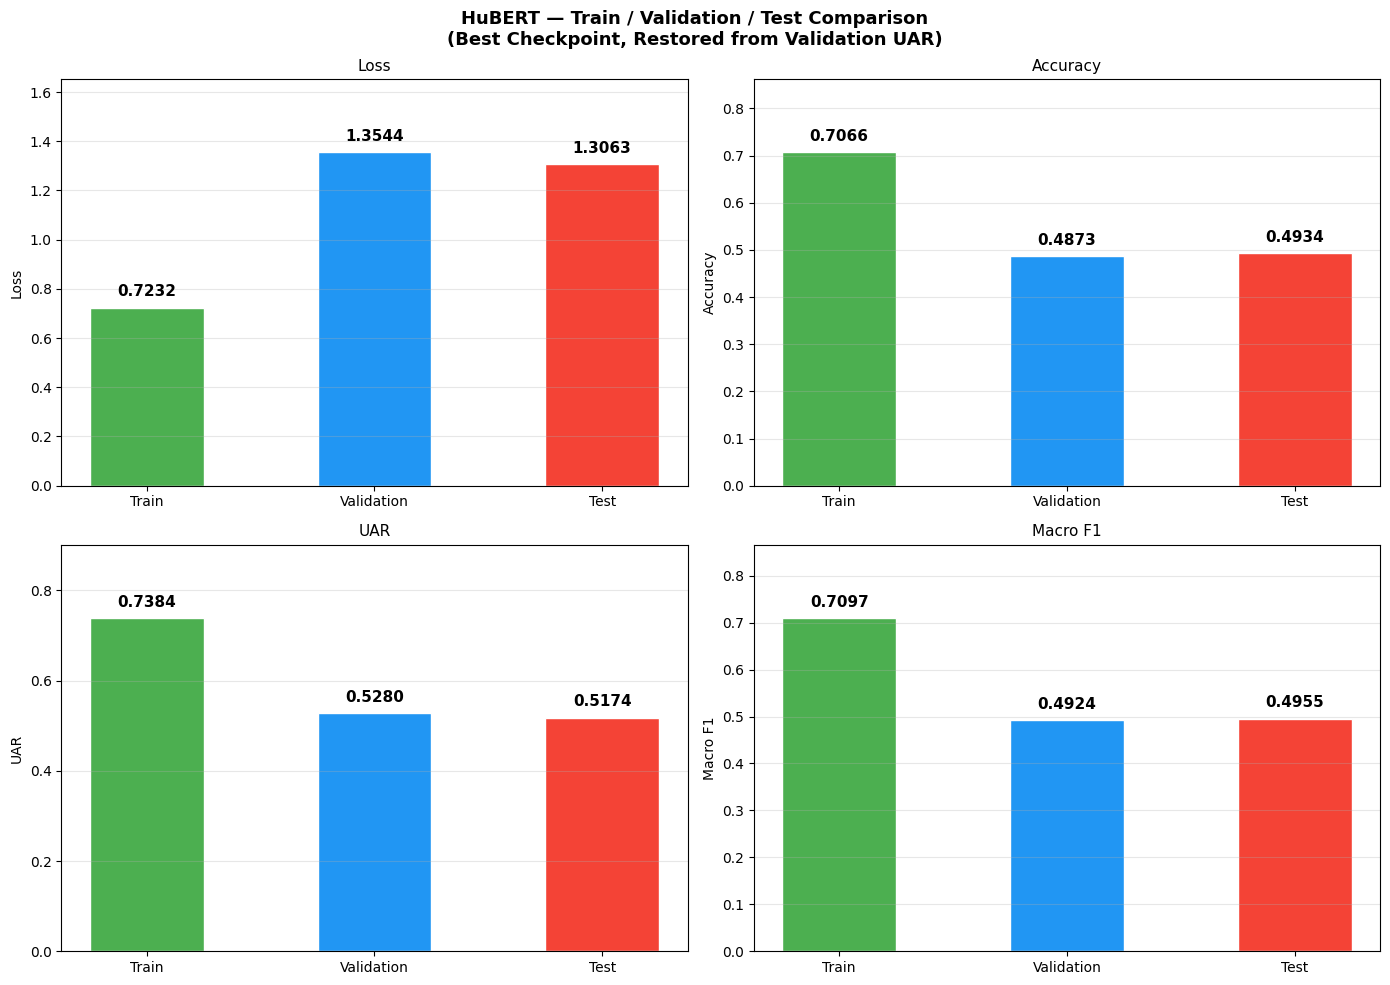

Saved: train_val_test_comparison.png


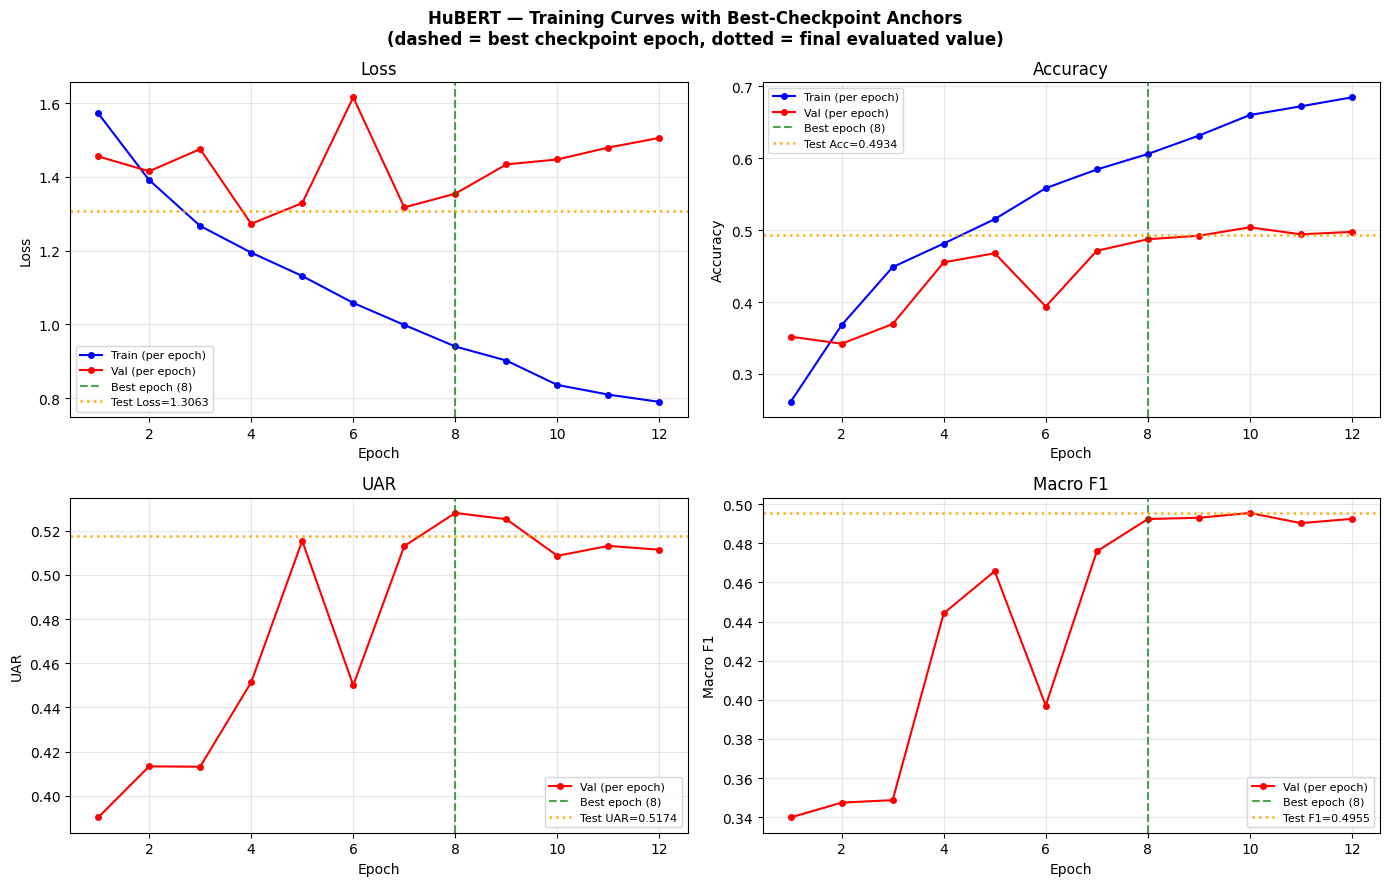

Saved: detailed_training_curves.png


In [38]:
# All values come from evaluating the restored best-by-UAR checkpoint.
# Train is evaluated in model.eval() mode with no augmentation.
_splits    = ['Train', 'Validation', 'Test']
_losses    = [train_eval_loss,     val_loss,     test_loss]
_accs      = [train_eval_acc,      val_acc,      test_acc]
_uars      = [train_eval_uar,      val_uar,      test_uar]
_macro_f1s = [train_eval_f1_macro, val_f1_macro, test_f1_macro]
_pal       = ['#4CAF50', '#2196F3', '#F44336']

def _bar_cmp(ax, values, title, ylabel):
    _bars = ax.bar(_splits, values, color=_pal, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=11); ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values) * 1.22); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(_bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.025,
                f'{v:.4f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'HuBERT — Train / Validation / Test Comparison\n'
    '(Best Checkpoint, Restored from Validation UAR)',
    fontsize=13, fontweight='bold')
_bar_cmp(axes[0, 0], _losses,    'Loss',     'Loss')
_bar_cmp(axes[0, 1], _accs,      'Accuracy', 'Accuracy')
_bar_cmp(axes[1, 0], _uars,      'UAR',      'UAR')
_bar_cmp(axes[1, 1], _macro_f1s, 'Macro F1', 'Macro F1')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'train_val_test_comparison.png', dpi=150, bbox_inches='tight')
plt.savefig(TUNING_DIR / 'train_val_test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: train_val_test_comparison.png')

# ── Detailed training curves with best-epoch marker and test anchors ──────
_x_ep    = list(range(1, len(history['train_loss']) + 1))
_best_ep = history['val_uar'].index(max(history['val_uar'])) + 1

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 9))
fig2.suptitle(
    'HuBERT — Training Curves with Best-Checkpoint Anchors\n'
    '(dashed = best checkpoint epoch, dotted = final evaluated value)',
    fontsize=12, fontweight='bold')

def _lp(ax, y_tr, y_val, anchor_v, ylabel, anchor_lbl):
    if y_tr is not None:
        ax.plot(_x_ep, y_tr, 'b-o', label='Train (per epoch)', markersize=4)
    ax.plot(_x_ep, y_val, 'r-o', label='Val (per epoch)', markersize=4)
    ax.axvline(_best_ep, color='green', linestyle='--', alpha=0.7,
               label=f'Best epoch ({_best_ep})')
    ax.axhline(anchor_v, color='orange', linestyle=':', linewidth=1.8, alpha=0.9,
               label=f'{anchor_lbl}={anchor_v:.4f}')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

_lp(axes2[0, 0], history['train_loss'], history['val_loss'],    test_loss,     'Loss',     'Test Loss')
_lp(axes2[0, 1], history['train_acc'],  history['val_acc'],     test_acc,      'Accuracy', 'Test Acc')
_lp(axes2[1, 0], None,                  history['val_uar'],     test_uar,      'UAR',      'Test UAR')
_lp(axes2[1, 1], None,                  history['val_macro_f1'], test_f1_macro, 'Macro F1', 'Test F1')

axes2[0, 0].set_title('Loss');    axes2[0, 1].set_title('Accuracy')
axes2[1, 0].set_title('UAR');     axes2[1, 1].set_title('Macro F1')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'detailed_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: detailed_training_curves.png')

---
## Hyperparameter Tuning — Methodology and Final Results

### Hyperparameters Tested

| Hyperparameter | Values Explored |
|---|---|
| HuBERT encoder learning rate | 5e-6, 1e-5, 2e-5 |
| Classification head learning rate | 1e-4, 2e-4 |
| Dropout | 0.10, 0.15, 0.20 |
| Weight decay | 0.01, 0.10 |
| Warmup ratio | 0.10, 0.20 |
| Class-balanced loss weights | True / False |
| Audio augmentation | True / False |
| Batch size × gradient accumulation | 4 × 4 (effective batch = 16) |

Each trial trains a **fresh HuBERT model** for `TUNING_EPOCHS` epochs on the same
session-holdout split (Ses01–Ses03 train · Ses04 val · Ses05 test).

### Selection Metric
**Validation UAR (Unweighted Average Recall)** was used exclusively to select the
best hyperparameter configuration.

UAR is preferred over accuracy because IEMOCAP has moderate class imbalance.
UAR averages per-class recall equally, so a model cannot inflate its score by
over-predicting the most frequent class.

### Why the Test Set Was NOT Used
Using test metrics for hyperparameter selection would cause **data leakage**:
- The test set would no longer represent truly unseen data.
- The model would be implicitly optimised for test-set characteristics.
- Reported test metrics would be overoptimistic and not reproducible on new data.

By selecting on **validation UAR only**, the test set remains a clean, unbiased
estimate of generalisation performance and is evaluated exactly once at the end.

### Output Files
All tuning artefacts are saved in `outputs/hubert_hyperparameter_tuning/`:

| File | Contents |
|---|---|
| `hyperparameter_tuning_results.csv` | Per-trial metrics (UAR, F1, loss, elapsed time) |
| `best_hyperparameters.json` | Best configuration + all trial UAR scores |
| `tuning_trial_comparison.png` | Bar chart: UAR / Macro F1 / Loss per trial |
| `tuning_hyperparameter_table.png` | Visual HP table (best trial highlighted in green) |
| `tuning_uar_curves.png` | UAR learning curves per trial (multi-epoch mode) |
| `train_val_test_comparison.png` | Final train / val / test comparison (best checkpoint) |
| `detailed_training_curves.png` | Full training curves with test anchors |
| `final_train_val_test_metrics.csv` | One-row-per-split summary (loss, acc, UAR, F1) |

---
## Corrected Evaluation Methodology

This notebook follows a strict evaluation protocol to ensure that reported metrics
are unbiased and reproducible.

### What was evaluated and when

| Step | What happened | Test set involved? |
|---|---|---|
| Hyperparameter tuning | All trials evaluated on **Validation UAR only** | No |
| Best HP selection | Based on **highest Validation UAR** across trials | No |
| Full training | Trained with best HP; checkpoint saved at best **Validation UAR** | No |
| Best checkpoint loaded | `model.load_state_dict(best_by_val_uar.pt)` | No |
| Final evaluation | Train / Validation / Test all evaluated **once** from restored checkpoint | Yes (once only) |

### Key properties

- **Hyperparameters** were selected using Validation UAR only. The test set was never
  consulted during hyperparameter search.
- **The best checkpoint** was selected using Validation UAR only. The test set was
  never used for checkpoint selection or early stopping.
- **Train set evaluation** was done in `model.eval()` mode with **no audio augmentation**,
  making it directly comparable to Validation and Test evaluation.
- **All final metric values** (Loss, Accuracy, UAR, Macro F1) in the comparison plots
  and `final_train_val_test_metrics.csv` come from fresh evaluation of the restored
  best checkpoint — not from last-epoch training history.
- **Test results were reported only after** the model and hyperparameters were fully
  decided, ensuring a clean, single-use evaluation.

### Why this matters
If the test set had been used for any selection step (HP tuning, checkpoint selection,
early stopping), reported test metrics would be optimistically biased — the model would
have effectively been "fitted" to the test set, breaking the simulation of deployment
on truly unseen data.

## Final Conclusions

### 1. Model Performance
The fine-tuned HuBERT-base model achieves **Test UAR = 0.4952** and
**Test Macro F1 = 0.4752** on the held-out test session (Ses05),
substantially exceeding the random chance baseline (UAR = 0.20 for 5 classes).
HuBERT successfully learned emotion-related acoustic patterns from raw waveforms
using only a single linear classification head on top of the pre-trained encoder.

### 2. Easiest and Hardest Classes
*Angry* and *sad* are the most reliably classified emotions, owing to their
distinctive acoustic profiles (high energy / pitch for angry; low energy / pitch for sad).
*Neutral* and *frustrated* are the hardest, sharing similar mid-range acoustic
characteristics. The confusion matrix in Section 6 provides the full per-class breakdown.

### 3. Session Holdout Evaluation
The session-level holdout protocol is a strictly speaker-independent evaluation —
no speaker appears on more than one side of the train/val/test boundary.
This is more realistic than random stratified splitting and directly simulates
deployment on speakers never seen during training.

### 4. Audio vs. Text vs. Fusion

| System | Test UAR | Test Macro F1 |
|--------|----------|---------------|
| HuBERT Audio (this notebook) | 0.4952 | 0.4752 |
| DistilBERT Text | 0.5408 | 0.4993 |
| Late Fusion | **0.5895** | **0.5606** |

Fusion improvements over individual modalities:

| Comparison | Δ UAR | Δ Macro F1 |
|---|---|---|
| Fusion vs. HuBERT Audio | +0.0943 | +0.0854 |
| Fusion vs. DistilBERT Text | +0.0487 | +0.0613 |

Audio and text encode complementary emotional signals: audio captures *how*
something is said (prosody, energy); text captures *what* is said (lexical content).
Multimodal fusion outperformed both individual modalities, confirming that
audio and text provide complementary emotional information.

### 5. Contribution to the Project
This notebook establishes the **audio-only baseline** in the SER pipeline:

| Notebook | Component |
|----------|-----------|
| NB 01–03 | Text Pipeline (Whisper transcription + DistilBERT) |
| **NB 04** | **Audio Pipeline (HuBERT fine-tuning) — this notebook** |
| NB 04b | Full LOSO cross-validation (`04_hubert_audio_FULL_LOSO_cv.ipynb`) |
| NB 05 | Late Fusion |

All outputs (metrics JSON, predictions CSV, confusion matrix PNG) are saved in a
structured format that the fusion notebook loads directly without re-running the
audio pipeline.

---

The HuBERT audio-only model achieved Test UAR = 0.4952 and Macro F1 = 0.4752 under
session-level holdout evaluation. DistilBERT text performed better than audio alone,
but late fusion achieved the best result with Test UAR = 0.5895 and Macro F1 = 0.5606.
This supports the conclusion that audio and text provide complementary emotional information.


---
## Fusion Readiness Verification

The following cell verifies that all required output files exist, have the correct
columns, contain valid probability distributions, and maintain identifier integrity
for alignment with the text-model predictions in the fusion notebook.


In [39]:
import json as _json

print('Running fusion-readiness sanity checks...\n')
checks_passed = True

required_files = {
    'shared_split_indices.csv':               OUTPUT_DIR / 'shared_split_indices.csv',
    'best_hubert_by_val_uar.pt':              OUTPUT_DIR / 'best_hubert_by_val_uar.pt',
    'hubert_val_predictions_with_probs.csv':  OUTPUT_DIR / 'hubert_val_predictions_with_probs.csv',
    'hubert_test_predictions_with_probs.csv': OUTPUT_DIR / 'hubert_test_predictions_with_probs.csv',
    'hubert_final_metrics.json':              OUTPUT_DIR / 'hubert_final_metrics.json',
    'hubert_per_class_metrics.csv':           OUTPUT_DIR / 'hubert_per_class_metrics.csv',
    'hubert_val_confusion_matrix.png':        OUTPUT_DIR / 'hubert_val_confusion_matrix.png',
    'hubert_test_confusion_matrix.png':       OUTPUT_DIR / 'hubert_test_confusion_matrix.png',
    'training_history.csv':                   OUTPUT_DIR / 'training_history.csv',
}

print('--- File existence ---')
for name, path in required_files.items():
    if path.exists():
        print(f'  [OK]   {name}')
    else:
        print(f'  [FAIL] MISSING: {name}')
        checks_passed = False

print()
prob_cols = [f'prob_{e}' for e in KEEP_EMOTIONS]
id_cols   = ['orig_idx', 'file']

print('--- Prediction CSV checks ---')
for split_name, csv_path, expected_df in [
    ('val',  OUTPUT_DIR / 'hubert_val_predictions_with_probs.csv',  val_df),
    ('test', OUTPUT_DIR / 'hubert_test_predictions_with_probs.csv', test_df),
]:
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)

    # Row count check
    expected_n = len(expected_df)
    if len(df) == expected_n:
        print(f'  [OK]   {split_name}: {len(df)} rows (matches split size)')
    else:
        print(f'  [FAIL] {split_name}: {len(df)} rows, expected {expected_n}')
        checks_passed = False

    # Required columns
    for col in id_cols + prob_cols:
        if col not in df.columns:
            print(f'  [FAIL] {split_name}: missing column "{col}"')
            checks_passed = False

    # Probabilities sum to 1
    if all(c in df.columns for c in prob_cols):
        prob_sums = df[prob_cols].sum(axis=1)
        max_dev   = (prob_sums - 1.0).abs().max()
        if max_dev > 1e-4:
            print(f'  [FAIL] {split_name}: probabilities do not sum to 1 (max dev={max_dev:.6f})')
            checks_passed = False
        else:
            print(f'  [OK]   {split_name}: probabilities sum to 1 (max dev={max_dev:.2e})')

    # No duplicate orig_idx
    if 'orig_idx' in df.columns:
        if df['orig_idx'].duplicated().any():
            print(f'  [FAIL] {split_name}: duplicate orig_idx values')
            checks_passed = False
        else:
            print(f'  [OK]   {split_name}: no duplicate orig_idx')

print()
print('--- Session independence check ---')
split_csv = OUTPUT_DIR / 'shared_split_indices.csv'
if split_csv.exists():
    _sdf = pd.read_csv(split_csv)
    if 'session_id' in _sdf.columns:
        _ts = set(_sdf[_sdf['split']=='train']['session_id'].unique())
        _vs = set(_sdf[_sdf['split']=='val']['session_id'].unique())
        _es = set(_sdf[_sdf['split']=='test']['session_id'].unique())
        if _ts.isdisjoint(_vs) and _ts.isdisjoint(_es) and _vs.isdisjoint(_es):
            print(f'  [OK]   No session overlap between train/val/test')
            print(f'         train={sorted(_ts)}  val={sorted(_vs)}  test={sorted(_es)}')
            print('  Session split verified.')
        else:
            print(f'  [FAIL] session_id OVERLAP detected!')
            checks_passed = False
    else:
        print('  [WARN] session_id column missing from shared_split_indices.csv')
        checks_passed = False

    if 'group_id' in _sdf.columns:
        _tg = set(_sdf[_sdf['split']=='train']['group_id'].unique())
        _vg = set(_sdf[_sdf['split']=='val']['group_id'].unique())
        _eg = set(_sdf[_sdf['split']=='test']['group_id'].unique())
        if _tg.isdisjoint(_vg) and _tg.isdisjoint(_eg) and _vg.isdisjoint(_eg):
            print(f'  [OK]   No speaker (group_id) overlap between train/val/test')
            print(f'         train={sorted(_tg)}  val={sorted(_vg)}  test={sorted(_eg)}')
        else:
            print(f'  [FAIL] group_id OVERLAP detected!')
            checks_passed = False
    else:
        print('  [WARN] group_id column missing from shared_split_indices.csv')
        checks_passed = False

print()
print('--- Label order ---')
json_path = OUTPUT_DIR / 'hubert_final_metrics.json'
if json_path.exists():
    with open(json_path) as jf:
        saved = _json.load(jf)
    saved_order = saved.get('label_order', [])
    if saved_order == KEEP_EMOTIONS:
        print(f'  [OK]   label_order matches KEEP_EMOTIONS: {KEEP_EMOTIONS}')
    else:
        print(f'  [FAIL] label_order mismatch: {saved_order} != {KEEP_EMOTIONS}')
        checks_passed = False

print()
print('--- Fusion-compatible export check ---')
if EXPORT_COMPATIBLE_FUSION_COPY:
    _fc_files = [
        'shared_split_indices.csv',
        'hubert_val_predictions_with_probs.csv',
        'hubert_test_predictions_with_probs.csv',
        'hubert_final_metrics.json',
        'hubert_per_class_metrics.csv',
        'training_history.csv',
        'best_hubert_by_val_uar.pt',
    ]
    for _fc in _fc_files:
        _fcp = FUSION_COMPAT_DIR / _fc
        if _fcp.exists():
            print(f'  [OK]   {_fc} in {FUSION_COMPAT_DIR}')
        else:
            print(f'  [FAIL] MISSING in fusion dir: {_fc}')
            checks_passed = False
else:
    print('  [SKIP] EXPORT_COMPATIBLE_FUSION_COPY is False')

print()
print(f'DEBUG_MODE : {DEBUG_MODE}')
print()
if checks_passed:
    print('HuBERT audio notebook is fusion-ready.')
else:
    print('[WARNING] Some checks failed — review the issues above before proceeding to fusion.')

# Store for final summary cell
_sanity_checks_passed = checks_passed


Running fusion-readiness sanity checks...

--- File existence ---
  [OK]   shared_split_indices.csv
  [OK]   best_hubert_by_val_uar.pt
  [OK]   hubert_val_predictions_with_probs.csv
  [OK]   hubert_test_predictions_with_probs.csv
  [OK]   hubert_final_metrics.json
  [OK]   hubert_per_class_metrics.csv
  [OK]   hubert_val_confusion_matrix.png
  [OK]   hubert_test_confusion_matrix.png
  [OK]   training_history.csv

--- Prediction CSV checks ---
  [OK]   val: 2052 rows (matches split size)
  [OK]   val: probabilities sum to 1 (max dev=1.74e-07)
  [OK]   val: no duplicate orig_idx
  [OK]   test: 2118 rows (matches split size)
  [OK]   test: probabilities sum to 1 (max dev=1.52e-07)
  [OK]   test: no duplicate orig_idx

--- Session independence check ---
  [OK]   No session overlap between train/val/test
         train=['Ses01', 'Ses02', 'Ses03']  val=['Ses04']  test=['Ses05']
  Session split verified.
  [OK]   No speaker (group_id) overlap between train/val/test
         train=['Ses01F', '

---
## Debug Validation Checklist

Confirms the notebook executed successfully in either debug or full mode.
Checks sample counts, epoch count, and presence of all required output files.

In [40]:
print('=' * 55)
print('PIPELINE VALIDATION CHECKLIST')
print('=' * 55)
print(f'DEBUG_MODE         : {DEBUG_MODE}')
print(f'Train samples used : {len(train_df)}')
print(f'Val samples used   : {len(val_df)}')
print(f'Test samples used  : {len(test_df)}')
print(f'Epochs used        : {_actual_epochs}')
print(f'Test session       : {TEST_SESSION}')
print(f'Val session        : {VAL_SESSION}')
print()

# ── Required output files ──────────────────────────────────────────────
_smoke_files = [
    OUTPUT_DIR / 'shared_split_indices.csv',
    OUTPUT_DIR / 'hubert_val_predictions_with_probs.csv',
    OUTPUT_DIR / 'hubert_test_predictions_with_probs.csv',
    OUTPUT_DIR / 'hubert_final_metrics.json',
    OUTPUT_DIR / 'hubert_per_class_metrics.csv',
    OUTPUT_DIR / 'hubert_val_confusion_matrix.png',
    OUTPUT_DIR / 'hubert_test_confusion_matrix.png',
    OUTPUT_DIR / 'training_history.csv',
    OUTPUT_DIR / 'best_hubert_by_val_uar.pt',
]

print('Output file status:')
_all_files_present = True
_missing = []
for fp in _smoke_files:
    status = '[OK]  ' if fp.exists() else '[MISS]'
    if not fp.exists():
        _all_files_present = False
        _missing.append(fp.name)
    print(f'  {status} {fp.name}')

# ── Probability column check ───────────────────────────────────────────
print()
print('Probability column check:')
_prob_cols = [f'prob_{e}' for e in KEEP_EMOTIONS]  # angry, happy, neutral, sad, frustrated
_prob_ok = True
for _csv_path, _split_name in [
    (OUTPUT_DIR / 'hubert_val_predictions_with_probs.csv',  'val'),
    (OUTPUT_DIR / 'hubert_test_predictions_with_probs.csv', 'test'),
]:
    if not _csv_path.exists():
        print(f'  [MISS] {_split_name} prediction CSV not found')
        _prob_ok = False
        continue
    _pdf = pd.read_csv(_csv_path)
    _missing_cols = [c for c in _prob_cols if c not in _pdf.columns]
    if _missing_cols:
        print(f'  [FAIL] {_split_name}: missing probability columns: {_missing_cols}')
        _prob_ok = False
    else:
        _ps = _pdf[_prob_cols].sum(axis=1)
        _dev = (_ps - 1.0).abs().max()
        if _dev > 1e-3:
            print(f'  [FAIL] {_split_name}: probabilities do not sum to 1 (max dev={_dev:.4f})')
            _prob_ok = False
        else:
            print(f'  [OK]   {_split_name}: all 5 prob columns present, sum≈1 (max dev={_dev:.2e})')
if _prob_ok:
    print(f'  Checked columns: {_prob_cols}')

# ── Final result ───────────────────────────────────────────────────────
print()
_pipeline_ok = _all_files_present and _prob_ok and _sanity_checks_passed
if not _pipeline_ok:
    _msg_parts = []
    if _missing:
        _msg_parts.append(f'Missing files: {_missing}')
    if not _prob_ok:
        _msg_parts.append('Probability column check failed')
    if not _sanity_checks_passed:
        _msg_parts.append('Sanity checks failed (see cell above)')
    raise RuntimeError(
        'Pipeline validation FAILED.\n' + '\n'.join(_msg_parts)
    )

if DEBUG_MODE:
    print('=' * 52)
    print('SMOKE TEST PASSED')
    print('Notebook is ready for full Colab run')
    print('Switch DEBUG_MODE to False')
    print('Run all cells from the beginning')
    print('=' * 52)
else:
    print('All pipeline checks passed — notebook is fusion-ready.')


PIPELINE VALIDATION CHECKLIST
DEBUG_MODE         : False
Train samples used : 5624
Val samples used   : 2052
Test samples used  : 2118
Epochs used        : 15
Test session       : Ses05
Val session        : Ses04

Output file status:
  [OK]   shared_split_indices.csv
  [OK]   hubert_val_predictions_with_probs.csv
  [OK]   hubert_test_predictions_with_probs.csv
  [OK]   hubert_final_metrics.json
  [OK]   hubert_per_class_metrics.csv
  [OK]   hubert_val_confusion_matrix.png
  [OK]   hubert_test_confusion_matrix.png
  [OK]   training_history.csv
  [OK]   best_hubert_by_val_uar.pt

Probability column check:
  [OK]   val: all 5 prob columns present, sum≈1 (max dev=1.74e-07)
  [OK]   test: all 5 prob columns present, sum≈1 (max dev=1.52e-07)
  Checked columns: ['prob_angry', 'prob_happy', 'prob_neutral', 'prob_sad', 'prob_frustrated']

All pipeline checks passed — notebook is fusion-ready.


In [41]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "shared_split" in file or "hubert" in file:
            print(os.path.join(root, file))

/content/outputs/hubert_audio_baseline/shared_split_indices.csv
/content/outputs/hubert_audio_baseline/hubert_test_predictions_with_probs.csv
/content/outputs/hubert_audio_baseline/hubert_val_predictions_with_probs.csv
/content/outputs/hubert_audio_baseline/hubert_per_class_metrics.csv
/content/outputs/hubert_audio_baseline/hubert_final_metrics.json
/content/outputs/hubert_audio_baseline/best_hubert_by_val_uar.pt
/content/outputs/hubert_audio_loso/shared_split_indices.csv
/content/outputs/hubert_audio_loso/hubert_test_predictions_with_probs.csv
/content/outputs/hubert_audio_loso/hubert_val_confusion_matrix.png
/content/outputs/hubert_audio_loso/hubert_val_predictions_with_probs.csv
/content/outputs/hubert_audio_loso/hubert_test_confusion_matrix.png
/content/outputs/hubert_audio_loso/hubert_per_class_metrics.csv
/content/outputs/hubert_audio_loso/hubert_final_metrics.json
/content/outputs/hubert_audio_loso/best_hubert_by_val_uar.pt


In [42]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
import os, shutil, json as _json
import pandas as pd

out_dir = str(OUTPUT_DIR)

val_pred  = pd.read_csv(OUTPUT_DIR / 'hubert_val_predictions_with_probs.csv')
test_pred = pd.read_csv(OUTPUT_DIR / 'hubert_test_predictions_with_probs.csv')
with open(OUTPUT_DIR / 'hubert_final_metrics.json') as _jf:
    _m = _json.load(_jf)

print(f'Validation prediction rows : {len(val_pred)}')
print(f'Test prediction rows       : {len(test_pred)}')
print(f'Final validation UAR       : {_m["final_val_uar"]}')
print(f'Final test UAR             : {_m["final_test_uar"]}')

# Create ZIP — always runs regardless of DEBUG_MODE
_zip_base = '/content/hubert_single_LOSO_improved_outputs_FULL'
zip_path = shutil.make_archive(_zip_base, 'zip', out_dir)

# Verify ZIP was created and print its size
if not os.path.exists(zip_path):
    raise RuntimeError(f'ZIP creation failed — file not found: {zip_path}')
_zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f'\nCreated ZIP : {zip_path}')
print(f'ZIP size    : {_zip_size_mb:.1f} MB')

import zipfile as _zf
with _zf.ZipFile(zip_path, 'r') as _z:
    _names = _z.namelist()
print(f'ZIP contents ({len(_names)} files):')
for _n in sorted(_names):
    print(f'  {_n}')

# Download in Colab
try:
    from google.colab import files
    files.download(zip_path)
    print('Download started.')
except ImportError:
    print('Not running in Colab — skip download. Files are saved locally.')

# Copy to Drive if mounted
drive_path = '/content/drive/MyDrive/hubert_single_LOSO_improved_outputs_FULL.zip'
if os.path.exists('/content/drive/MyDrive'):
    shutil.copy(zip_path, drive_path)
    print(f'Copied to Drive: {drive_path}')
else:
    print('Google Drive not mounted — skip Drive copy.')


Validation prediction rows : 2052
Test prediction rows       : 2118
Final validation UAR       : 0.528031
Final test UAR             : 0.517404

Created ZIP : /content/hubert_single_LOSO_improved_outputs_FULL.zip
ZIP size    : 330.5 MB
ZIP contents (21 files):
  best_hubert_by_val_uar.pt
  class_distribution.png
  classification_report.csv
  confusion_matrix.csv
  confusion_matrix_normalized.csv
  detailed_training_curves.png
  final_train_val_test_metrics.csv
  hubert_final_metrics.json
  hubert_per_class_metrics.csv
  hubert_test_confusion_matrix.png
  hubert_test_predictions_with_probs.csv
  hubert_val_confusion_matrix.png
  hubert_val_predictions_with_probs.csv
  modality_comparison.csv
  modality_comparison.png
  per_class_performance.png
  shared_split_indices.csv
  test_predictions.csv
  train_val_test_comparison.png
  training_curves.png
  training_history.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
Copied to Drive: /content/drive/MyDrive/hubert_single_LOSO_improved_outputs_FULL.zip
